In [1]:
import pandas as pd

In [2]:
superstore_df = pd.read_csv("train.csv")
games_df = pd.read_csv("vgsales.csv/vgsales.csv")

In [3]:
print("Superstore shape:", superstore_df.shape)
print("Video games shape:", games_df.shape)

Superstore shape: (9800, 18)
Video games shape: (16598, 11)


In [4]:
display(superstore_df.head())
display(games_df.head())

print(superstore_df.columns.tolist())
print(games_df.columns.tolist())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [5]:
superstore_missing = (
    superstore_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

games_missing = (
    games_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("SUPERSTORE MISSING VALUES")
display(superstore_missing[superstore_missing > 0])

print("VIDEO GAME MISSING VALUES")
display(games_missing[games_missing > 0])

SUPERSTORE MISSING VALUES


Postal Code    11
dtype: int64

VIDEO GAME MISSING VALUES


Year         271
Publisher     58
dtype: int64

In [6]:
superstore_missing_percentage = (
    superstore_df.isnull().mean() * 100
).sort_values(ascending=False)

games_missing_percentage = (
    games_df.isnull().mean() * 100
).sort_values(ascending=False)

print("Superstore missing percentage:")
display(
    superstore_missing_percentage[
        superstore_missing_percentage > 0
    ]
)

print("Video games missing percentage:")
display(
    games_missing_percentage[
        games_missing_percentage > 0
    ]
)

Superstore missing percentage:


Postal Code    0.112245
dtype: float64

Video games missing percentage:


Year         1.632727
Publisher    0.349440
dtype: float64

In [7]:
superstore_df["Postal Code"] = (
    superstore_df["Postal Code"]
    .astype("Int64")
)

In [8]:
games_df["Year"] = pd.to_numeric(
    games_df["Year"],
    errors="coerce"
).astype("Int64")

In [9]:
games_df["Publisher"] = (
    games_df["Publisher"]
    .fillna("Unknown")
)

In [10]:
games_time_df = games_df.dropna(
    subset=["Year"]
).copy()

In [11]:
print(
    "Complete duplicate rows in Superstore:",
    superstore_df.duplicated().sum()
)

print(
    "Complete duplicate rows in Video Games:",
    games_df.duplicated().sum()
)

Complete duplicate rows in Superstore: 0
Complete duplicate rows in Video Games: 0


In [12]:
print(
    "Zero or negative sales:",
    (superstore_df["Sales"] <= 0).sum()
)
display(
    superstore_df[
        superstore_df["Sales"] <= 0
    ]
)

Zero or negative sales: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales


In [13]:
invalid_shipping = superstore_df[
    superstore_df["Ship Date"] <
    superstore_df["Order Date"]
]

print(
    "Invalid shipping date rows:",
    invalid_shipping.shape[0]
)

display(invalid_shipping.head())

Invalid shipping date rows: 1139


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
18,19,CA-2015-143336,27/08/2015,01/09/2015,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,OFF-AR-10003056,Office Supplies,Art,Newell 341,8.560
19,20,CA-2015-143336,27/08/2015,01/09/2015,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480
20,21,CA-2015-143336,27/08/2015,01/09/2015,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,OFF-BI-10002215,Office Supplies,Binders,"Wilson Jones Hanging View Binder, White, 1""",22.720
66,67,US-2016-164175,30/04/2016,05/05/2016,Standard Class,PS-18970,Paul Stevenson,Home Office,United States,Chicago,Illinois,60610,Central,FUR-CH-10001146,Furniture,Chairs,"Global Value Mid-Back Manager's Chair, Gray",213.115
72,73,US-2016-134026,26/04/2016,02/05/2016,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Memphis,Tennessee,38109,South,FUR-CH-10000513,Furniture,Chairs,High-Back Leather Manager's Chair,831.936


In [14]:
superstore_df["Order Date"]

0       08/11/2017
1       08/11/2017
2       12/06/2017
3       11/10/2016
4       11/10/2016
           ...    
9795    21/05/2017
9796    12/01/2016
9797    12/01/2016
9798    12/01/2016
9799    12/01/2016
Name: Order Date, Length: 9800, dtype: object

In [15]:

superstore_df["Order Date"] = pd.to_datetime(
    superstore_df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

superstore_df["Ship Date"] = pd.to_datetime(
    superstore_df["Ship Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [16]:
print(superstore_df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [17]:
print("Invalid Order Dates:", superstore_df["Order Date"].isna().sum())
print("Invalid Ship Dates:", superstore_df["Ship Date"].isna().sum())

Invalid Order Dates: 0
Invalid Ship Dates: 0


In [18]:
superstore_df["Year"] = superstore_df["Order Date"].dt.year
superstore_df["Month"] = superstore_df["Order Date"].dt.month
superstore_df["Month Name"] = superstore_df["Order Date"].dt.month_name()

superstore_df["Week Number"] = (
    superstore_df["Order Date"]
    .dt.isocalendar()
    .week
    .astype("Int64")
)

superstore_df["Day of Week"] = superstore_df["Order Date"].dt.day_name()
superstore_df["Quarter"] = superstore_df["Order Date"].dt.quarter

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


superstore_df["Season"] = superstore_df["Month"].apply(get_season)

In [20]:
display(
    superstore_df[
        [
            "Order Date",
            "Year",
            "Month",
            "Month Name",
            "Week Number",
            "Day of Week",
            "Quarter",
            "Season"
        ]
    ].head()
)

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [21]:
superstore_df["Shipping Days"] = (
    superstore_df["Ship Date"] - superstore_df["Order Date"]
).dt.days

In [22]:
display(
    superstore_df[
        ["Order Date", "Ship Date", "Shipping Days", "Region"]
    ].head()
)

,Order Date,Ship Date,Shipping Days,Region
0,2017-11-08,2017-11-11,3,South
1,2017-11-08,2017-11-11,3,South
2,2017-06-12,2017-06-16,4,West
3,2016-10-11,2016-10-18,7,South
4,2016-10-11,2016-10-18,7,South


In [23]:
invalid_shipping = superstore_df[
    superstore_df["Shipping Days"] < 0
]

print("Invalid shipping records:", len(invalid_shipping))

Invalid shipping records: 0


In [24]:
average_shipping_days = superstore_df["Shipping Days"].mean()

print(
    "Average shipping time:",
    round(average_shipping_days, 2),
    "days"
)

Average shipping time: 3.96 days


In [25]:
shipping_by_region = (
    superstore_df
    .groupby("Region")["Shipping Days"]
    .agg(["mean", "median", "min", "max", "count"])
    .round(2)
    .sort_values("mean")
)

display(shipping_by_region)

,mean,median,min,max,count
Region,,,,,
East,3.91,4.0,0,7,2785
West,3.93,4.0,0,7,3140
South,3.96,4.0,0,7,1598
Central,4.07,4.0,0,7,2277


In [26]:
daily_sales = (
    superstore_df
    .groupby("Order Date", as_index=False)["Sales"]
    .sum()
    .sort_values("Order Date")
)

daily_sales.rename(
    columns={"Sales": "Daily Sales"},
    inplace=True
)

display(daily_sales.head())

,Order Date,Daily Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [27]:
weekly_sales = (
    superstore_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.rename(
    columns={
        "Order Date": "Week",
        "Sales": "Weekly Sales"
    },
    inplace=True
)

display(weekly_sales.head())

,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [28]:
monthly_sales = (
    superstore_df
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.rename(
    columns={
        "Order Date": "Month",
        "Sales": "Monthly Sales"
    },
    inplace=True
)

display(monthly_sales.head())

,Month,Monthly Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [29]:
print("Daily sales rows:", len(daily_sales))
print("Weekly sales rows:", len(weekly_sales))
print("Monthly sales rows:", len(monthly_sales))

Daily sales rows: 1230
Weekly sales rows: 209
Monthly sales rows: 48


In [30]:
category_revenue = (
    superstore_df
    .groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_revenue["Sales"] = category_revenue["Sales"].round(2)

display(category_revenue)

,Category,Sales
2,Technology,827455.87
0,Furniture,728658.58
1,Office Supplies,705422.33


In [31]:
highest_category = category_revenue.iloc[0]

print("Highest revenue category:", highest_category["Category"])
print("Total revenue:", highest_category["Sales"])

Highest revenue category: Technology
Total revenue: 827455.87


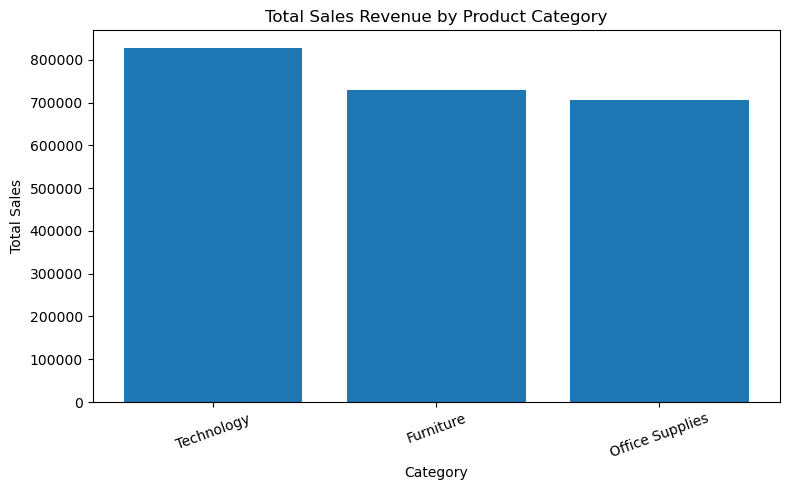

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_revenue["Category"],
    category_revenue["Sales"]
)

plt.title("Total Sales Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [33]:
superstore_df.to_csv(
    "cleaned_superstore.csv",
    index=False
)

games_df.to_csv(
    "cleaned_vgsales.csv",
    index=False
)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


In [34]:
#Initial Business Findings

#The average order-to-shipment time is 3.96 days. Shipping performance is
#relatively consistent across all regions, with East recording the shortest
#average shipping time of 3.91 days and Central recording the longest at
#4.07 days. The difference is small, suggesting that regional shipping
#operations are generally standardized.
#Technology is the highest-revenue product category, generating total sales
#of 827,455.87. Furniture ranks second with 728,658.58, followed by Office
#Supplies with 705,422.33. This suggests that Technology products should
#receive greater attention in inventory planning and demand forecasting.

In [35]:
print("Daily sales rows:", len(daily_sales))
print("Weekly sales rows:", len(weekly_sales))
print("Monthly sales rows:", len(monthly_sales))

print(
    "Monthly date range:",
    monthly_sales["Month"].min(),
    "to",
    monthly_sales["Month"].max()
)

Daily sales rows: 1230
Weekly sales rows: 209
Monthly sales rows: 48
Monthly date range: 2015-01-01 00:00:00 to 2018-12-01 00:00:00


In [36]:
region_year_sales = (
    superstore_df
    .groupby(["Year", "Region"])["Sales"]
    .sum()
    .unstack()
    .sort_index()
)

display(region_year_sales.round(2))

Region,Central,East,South,West
Year,,,,
2015,102920.52,127652.82,103374.91,145907.96
2016,102425.17,153225.18,70076.08,133709.57
2017,145673.88,178511.54,93535.90,182471.23
2018,141627.34,210129.19,122164.57,248130.93


In [37]:
region_yoy_growth = (
    region_year_sales
    .pct_change() * 100
)

display(region_yoy_growth.round(2))

Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.48,20.03,-32.21,-8.36
2017,42.22,16.50,33.48,36.47
2018,-2.78,17.71,30.61,35.98


In [38]:
region_growth_summary = pd.DataFrame({
    "Average Growth (%)": region_yoy_growth.mean(),
    "Growth Volatility (%)": region_yoy_growth.std(),
    "Positive Growth Years": (region_yoy_growth > 0).sum()
})

region_growth_summary = (
    region_growth_summary
    .sort_values(
        by=[
            "Positive Growth Years",
            "Growth Volatility (%)",
            "Average Growth (%)"
        ],
        ascending=[False, True, False]
    )
)

display(region_growth_summary.round(2))

,Average Growth (%),Growth Volatility (%),Positive Growth Years
Region,,,
East,18.08,1.79,3
West,21.36,25.74,2
South,10.62,37.12,2
Central,12.99,25.35,1


In [39]:
most_consistent_region = region_growth_summary.index[0]

print(
    "Region with the most consistent sales growth:",
    most_consistent_region
)

Region with the most consistent sales growth: East


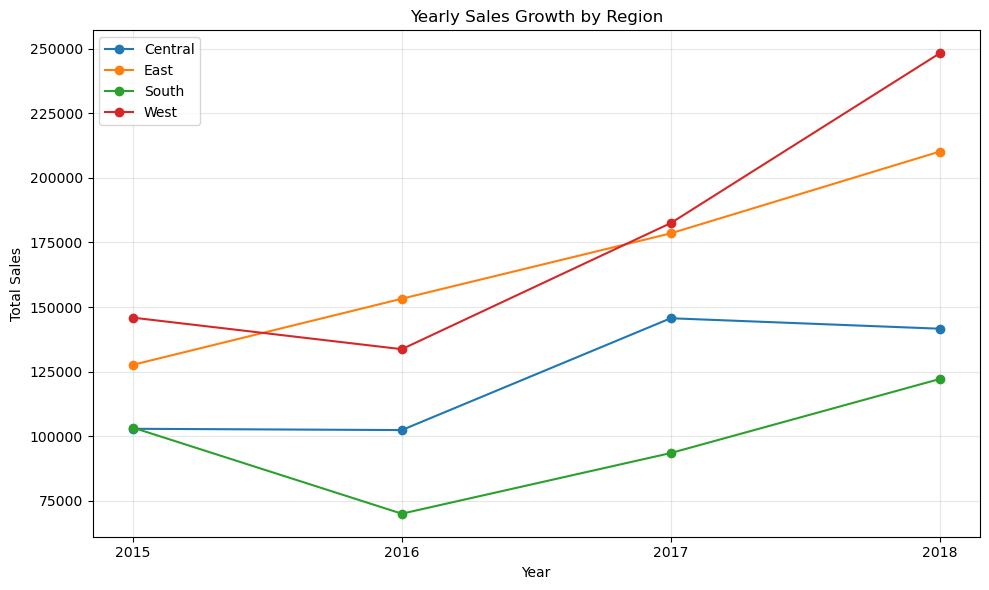

In [40]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(10, 6))

for region in region_year_sales.columns:
    plt.plot(
        region_year_sales.index,
        region_year_sales[region],
        marker="o",
        label=region
    )

plt.title("Yearly Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(region_year_sales.index)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/yearly_region_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
year_month_sales = (
    superstore_df
    .groupby(["Year", "Month", "Month Name"], as_index=False)["Sales"]
    .sum()
)

display(year_month_sales.head())

,Year,Month,Month Name,Sales
0,2015,1,January,14205.707
1,2015,2,February,4519.892
2,2015,3,March,55205.797
3,2015,4,April,27906.855
4,2015,5,May,23644.303


In [42]:
month_summary = (
    year_month_sales
    .groupby(["Month", "Month Name"], as_index=False)
    .agg(
        Average_Sales=("Sales", "mean"),
        Sales_Volatility=("Sales", "std"),
        Minimum_Sales=("Sales", "min"),
        Maximum_Sales=("Sales", "max")
    )
    .sort_values("Month")
)

display(month_summary.round(2))

,Month,Month Name,Average_Sales,Sales_Volatility,Minimum_Sales,Maximum_Sales
0,1,January,23572.91,13410.41,14205.71,43476.47
1,2,February,14842.78,8304.73,4519.89,22978.82
2,3,March,49393.40,11796.12,32339.32,58863.41
3,4,April,34070.75,4524.30,27906.86,38679.77
4,5,May,38521.68,14738.49,23644.30,56656.91
5,6,June,36459.38,10299.35,23599.37,48190.73
6,7,July,36383.92,6885.69,28608.26,44825.10
7,8,August,39328.98,16179.17,27117.54,62837.85
8,9,September,75025.85,10689.30,63133.61,86152.89
9,10,October,49874.07,22728.12,31011.74,77448.13


In [43]:
top_months_each_year = (
    year_month_sales
    .sort_values(
        ["Year", "Sales"],
        ascending=[True, False]
    )
    .groupby("Year")
    .head(3)
)

display(top_months_each_year)

,Year,Month,Month Name,Sales
8,2015,9,September,81623.5268
10,2015,11,November,77907.6607
11,2015,12,December,68167.0585
22,2016,11,November,75249.3995
23,2016,12,December,74543.6012
20,2016,9,September,63133.6060
35,2017,12,December,95739.1210
34,2017,11,November,79066.4958
32,2017,9,September,69193.3909
46,2018,11,November,117938.1550


In [44]:
spike_frequency = (
    top_months_each_year
    .groupby(["Month", "Month Name"])
    .size()
    .reset_index(name="Times in Yearly Top 3")
    .sort_values(
        ["Times in Yearly Top 3", "Month"],
        ascending=[False, True]
    )
)

display(spike_frequency)

,Month,Month Name,Times in Yearly Top 3
0,9,September,4
1,11,November,4
2,12,December,4


In [45]:
seasonality_result = (
    month_summary
    .merge(
        spike_frequency,
        on=["Month", "Month Name"],
        how="left"
    )
)

seasonality_result["Times in Yearly Top 3"] = (
    seasonality_result["Times in Yearly Top 3"]
    .fillna(0)
    .astype(int)
)

seasonality_result = (
    seasonality_result
    .sort_values(
        ["Times in Yearly Top 3", "Average_Sales"],
        ascending=[False, False]
    )
)

display(seasonality_result.round(2))

,Month,Month Name,Average_Sales,Sales_Volatility,Minimum_Sales,Maximum_Sales,Times in Yearly Top 3
10,11,November,87540.43,20328.05,75249.40,117938.16,4
11,12,December,80370.04,11918.42,68167.06,95739.12,4
8,9,September,75025.85,10689.30,63133.61,86152.89,4
9,10,October,49874.07,22728.12,31011.74,77448.13,0
2,3,March,49393.40,11796.12,32339.32,58863.41,0
7,8,August,39328.98,16179.17,27117.54,62837.85,0
4,5,May,38521.68,14738.49,23644.30,56656.91,0
5,6,June,36459.38,10299.35,23599.37,48190.73,0
6,7,July,36383.92,6885.69,28608.26,44825.10,0
3,4,April,34070.75,4524.30,27906.86,38679.77,0


In [46]:
consistent_spike_months = seasonality_result.head(3)

print("Most consistent sales spike months:")

display(
    consistent_spike_months[
        [
            "Month Name",
            "Average_Sales",
            "Times in Yearly Top 3"
        ]
    ].round(2)
)

Most consistent sales spike months:


,Month Name,Average_Sales,Times in Yearly Top 3
10,November,87540.43,4
11,December,80370.04,4
8,September,75025.85,4


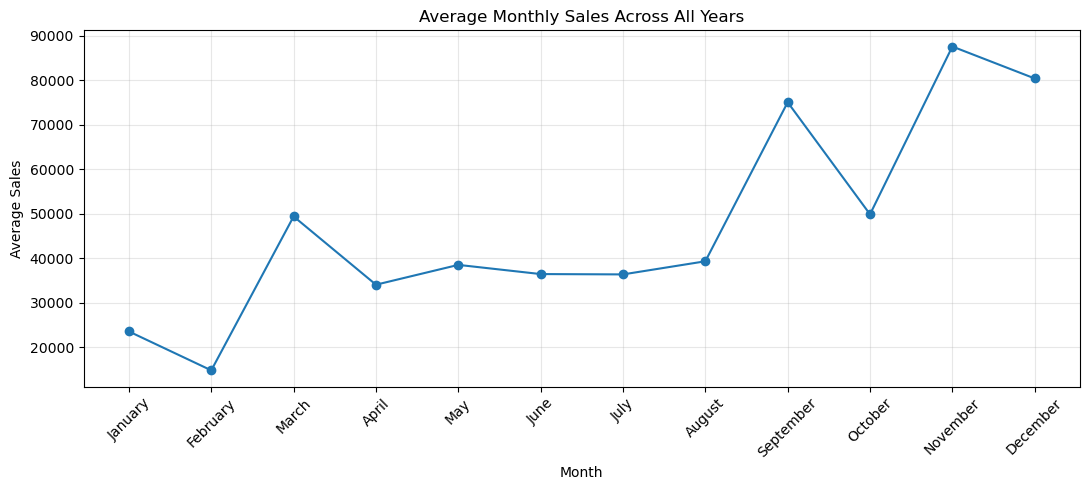

In [47]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_summary["Month Name"] = pd.Categorical(
    month_summary["Month Name"],
    categories=month_order,
    ordered=True
)

month_summary = month_summary.sort_values("Month Name")

plt.figure(figsize=(11, 5))

plt.plot(
    month_summary["Month Name"],
    month_summary["Average_Sales"],
    marker="o"
)

plt.title("Average Monthly Sales Across All Years")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
monthly_ts = (
    superstore_df
    .set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .asfreq("MS")
)

print("Number of months:", len(monthly_ts))
print("Missing months:", monthly_ts.isna().sum())

display(monthly_ts.head())

Number of months: 48
Missing months: 0


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

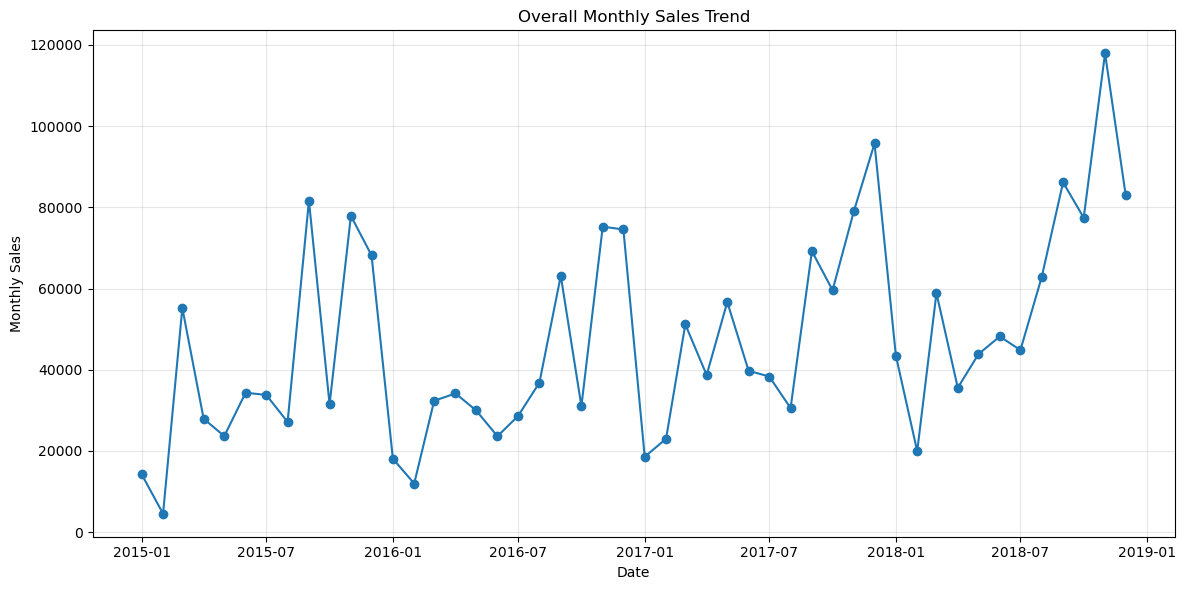

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    marker="o"
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

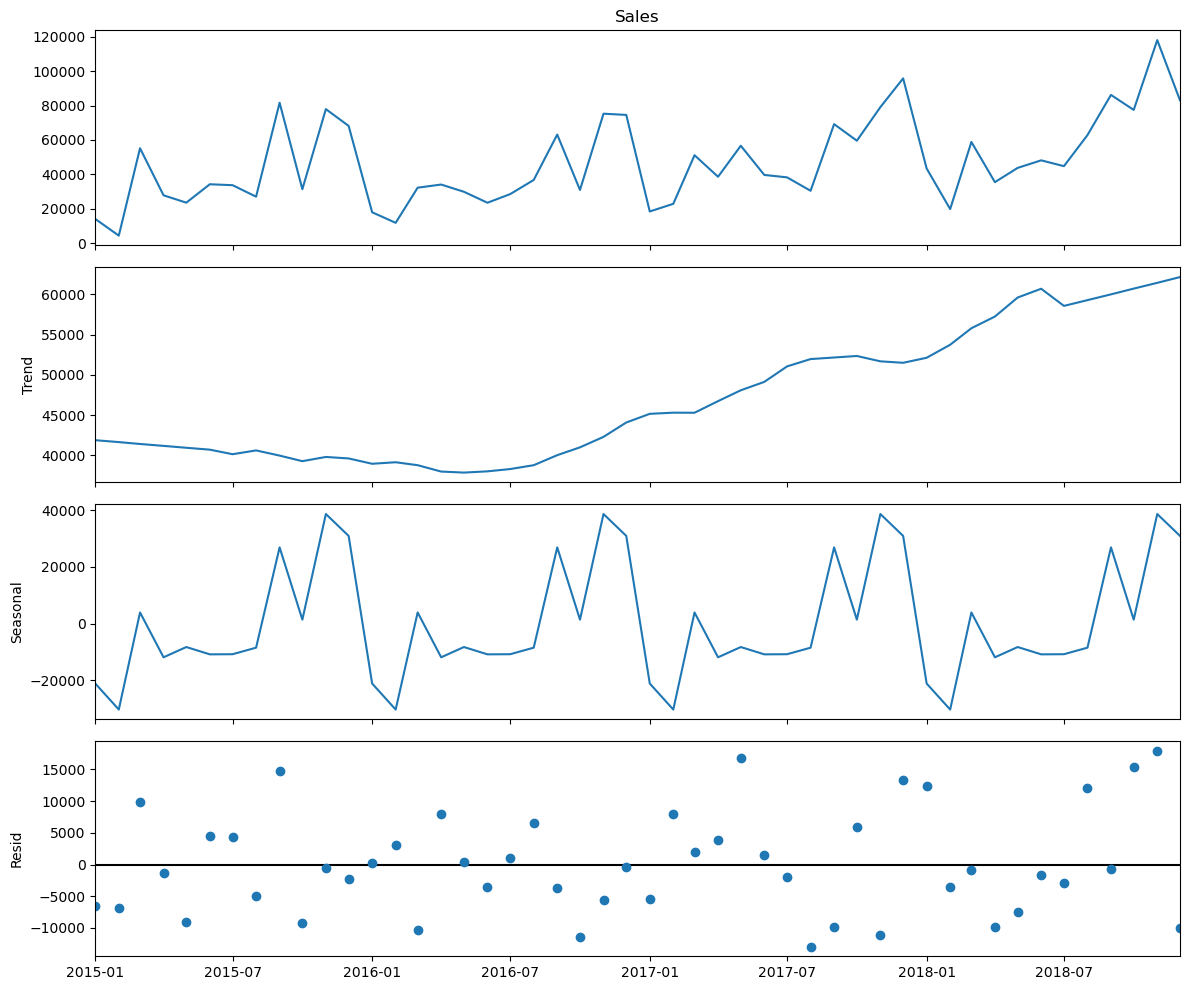

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

decomposition_plot = decomposition.plot()
decomposition_plot.set_size_inches(12, 10)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
seasonal_component = decomposition.seasonal.copy()

seasonal_by_month = (
    seasonal_component
    .groupby(seasonal_component.index.month)
    .mean()
)

seasonal_month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

seasonal_summary = pd.DataFrame({
    "Month Number": seasonal_by_month.index,
    "Month Name": [
        seasonal_month_names[month]
        for month in seasonal_by_month.index
    ],
    "Average Seasonal Effect": seasonal_by_month.values
})

seasonal_summary = seasonal_summary.sort_values(
    "Average Seasonal Effect",
    ascending=False
)

display(seasonal_summary.round(2))

,Month Number,Month Name,Average Seasonal Effect
10,11,November,38584.19
11,12,December,30880.07
8,9,September,26835.12
2,3,March,3920.57
9,10,October,1386.66
4,5,May,-8256.05
7,8,August,-8484.16
6,7,July,-10784.83
5,6,June,-10831.42
3,4,April,-11869.63


In [52]:
residuals = decomposition.resid.dropna()

largest_residuals = (
    residuals
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

residual_noise_table = pd.DataFrame({
    "Month": largest_residuals.index,
    "Absolute Residual": largest_residuals.values,
    "Original Residual": residuals.loc[largest_residuals.index].values
})

display(residual_noise_table.round(2))

,Month,Absolute Residual,Original Residual
0,2018-11-01,17919.60,17919.60
1,2017-05-01,16822.25,16822.25
2,2018-10-01,15343.35,15343.35
3,2015-09-01,14812.09,14812.09
4,2017-12-01,13356.43,13356.43


In [53]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name="Time Series"):
    result = adfuller(series.dropna())

    output = {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Number of Lags": result[2],
        "Number of Observations": result[3]
    }

    print(f"ADF Test: {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Number of Lags: {result[2]}")
    print(f"Number of Observations: {result[3]}")

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")

    if result[1] <= 0.05:
        print("\nConclusion: The series is stationary.")
    else:
        print("\nConclusion: The series is non-stationary.")

    return output

In [54]:
original_adf_result = run_adf_test(
    monthly_ts,
    "Original Monthly Sales"
)

ADF Test: Original Monthly Sales
ADF Statistic: -4.4161
p-value: 0.0003
Number of Lags: 0
Number of Observations: 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Conclusion: The series is stationary.


In [55]:
monthly_diff = monthly_ts.diff().dropna()

display(monthly_diff.head())

Order Date
2015-02-01    -9685.8150
2015-03-01    50685.9050
2015-04-01   -27298.9420
2015-05-01    -4262.5520
2015-06-01    10678.6326
Freq: MS, Name: Sales, dtype: float64

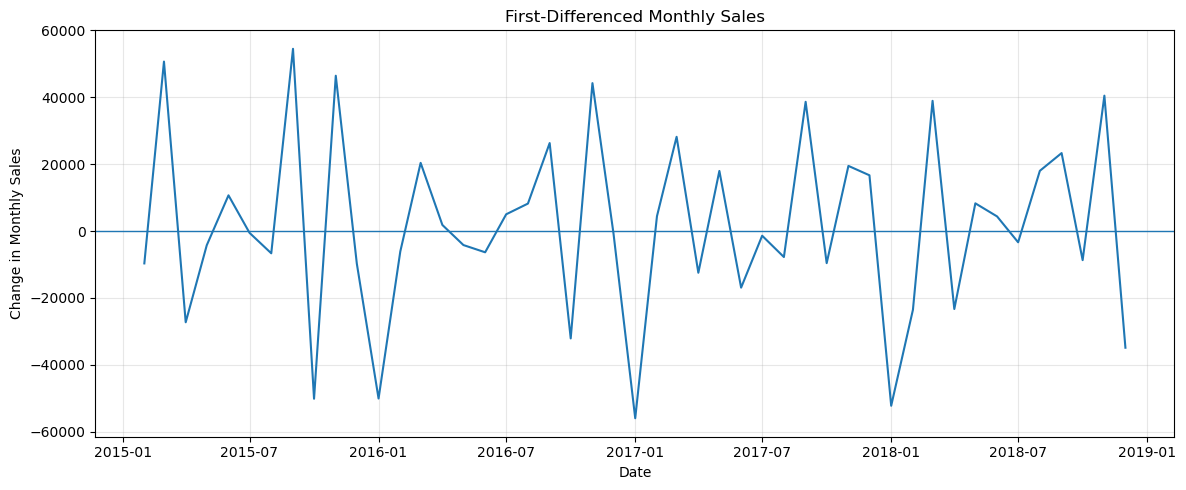

In [56]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_diff.index,
    monthly_diff.values
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("First-Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Change in Monthly Sales")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/differenced_monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
monthly_ts = (
    superstore_df
    .set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .asfreq("MS")
)

monthly_ts = monthly_ts.astype(float)

train_size = len(monthly_ts) - 6

train_ts = monthly_ts.iloc[:train_size]
test_ts = monthly_ts.iloc[train_size:]

print("Total months:", len(monthly_ts))
print("Training months:", len(train_ts))
print("Testing months:", len(test_ts))

print("\nTraining period:")
print(train_ts.index.min(), "to", train_ts.index.max())

print("\nTesting period:")
print(test_ts.index.min(), "to", test_ts.index.max())

display(test_ts)

Total months: 48
Training months: 42
Testing months: 6

Training period:
2015-01-01 00:00:00 to 2018-06-01 00:00:00

Testing period:
2018-07-01 00:00:00 to 2018-12-01 00:00:00


Order Date
2018-07-01     44825.1040
2018-08-01     62837.8480
2018-09-01     86152.8880
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64

In [58]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


def calculate_forecast_metrics(actual, predicted, model_name):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    non_zero_mask = actual != 0

    mape = np.mean(
        np.abs(
            (
                actual[non_zero_mask] -
                predicted[non_zero_mask]
            ) /
            actual[non_zero_mask]
        )
    ) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [59]:
import warnings
import itertools

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [60]:
p_values = [0, 1, 2]
d_values = [0]
q_values = [0, 1, 2]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

seasonal_period = 12

best_aic = float("inf")
best_order = None
best_seasonal_order = None
sarima_search_results = []

for p, d, q in itertools.product(
    p_values,
    d_values,
    q_values
):
    for P, D, Q in itertools.product(
        P_values,
        D_values,
        Q_values
    ):
        order = (p, d, q)

        seasonal_order = (
            P,
            D,
            Q,
            seasonal_period
        )

        try:
            model = SARIMAX(
                train_ts,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            sarima_search_results.append({
                "Order": order,
                "Seasonal Order": seasonal_order,
                "AIC": fitted_model.aic
            })

            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_order = order
                best_seasonal_order = seasonal_order

        except Exception:
            continue

print("Best SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Best AIC:", round(best_aic, 2))

Best SARIMA order: (1, 0, 2)
Best seasonal order: (0, 1, 1, 12)
Best AIC: 331.37


In [61]:
sarima_results_df = pd.DataFrame(
    sarima_search_results
).sort_values("AIC")

display(sarima_results_df.head(10))

,Order,Seasonal Order,AIC
43,"(1, 0, 2)","(0, 1, 1, 12)",331.368175
67,"(2, 0, 2)","(0, 1, 1, 12)",332.237297
19,"(0, 0, 2)","(0, 1, 1, 12)",332.514484
47,"(1, 0, 2)","(1, 1, 1, 12)",333.162915
23,"(0, 0, 2)","(1, 1, 1, 12)",333.454798
71,"(2, 0, 2)","(1, 1, 1, 12)",334.190981
35,"(1, 0, 1)","(0, 1, 1, 12)",350.811049
11,"(0, 0, 1)","(0, 1, 1, 12)",351.646276
39,"(1, 0, 1)","(1, 1, 1, 12)",352.187696
62,"(2, 0, 1)","(1, 1, 0, 12)",352.298429


In [62]:
sarima_model = SARIMAX(
    train_ts,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   42
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 12)   Log Likelihood                -160.684
Date:                              Sun, 12 Jul 2026   AIC                            331.368
Time:                                      19:36:57   BIC                            334.908
Sample:                                  01-01-2015   HQIC                           331.330
                                       - 06-01-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5212      0.319      1.635      0.102      -0.104       1.146
ma.L1          0.02

In [63]:
sarima_test_result = sarima_fit.get_forecast(
    steps=len(test_ts)
)

sarima_test_predictions = (
    sarima_test_result.predicted_mean
)

sarima_test_predictions.index = test_ts.index

sarima_test_confidence = (
    sarima_test_result.conf_int()
)

sarima_test_confidence.index = test_ts.index

In [64]:
sarima_test_comparison = pd.DataFrame({
    "Actual Sales": test_ts,
    "SARIMA Prediction": sarima_test_predictions
})

display(sarima_test_comparison.round(2))

,Actual Sales,SARIMA Prediction
Order Date,,
2018-07-01,44825.10,38669.24
2018-08-01,62837.85,41200.88
2018-09-01,86152.89,69794.53
2018-10-01,77448.13,48175.00
2018-11-01,117938.16,73701.57
2018-12-01,83030.39,81398.49


In [65]:
sarima_metrics = calculate_forecast_metrics(
    test_ts.values,
    sarima_test_predictions.values,
    "SARIMA"
)

sarima_metrics_df = pd.DataFrame(
    [sarima_metrics]
)

display(sarima_metrics_df.round(2))

,Model,MAE,RMSE,MAPE
0,SARIMA,19882.14,24461.21,24.07


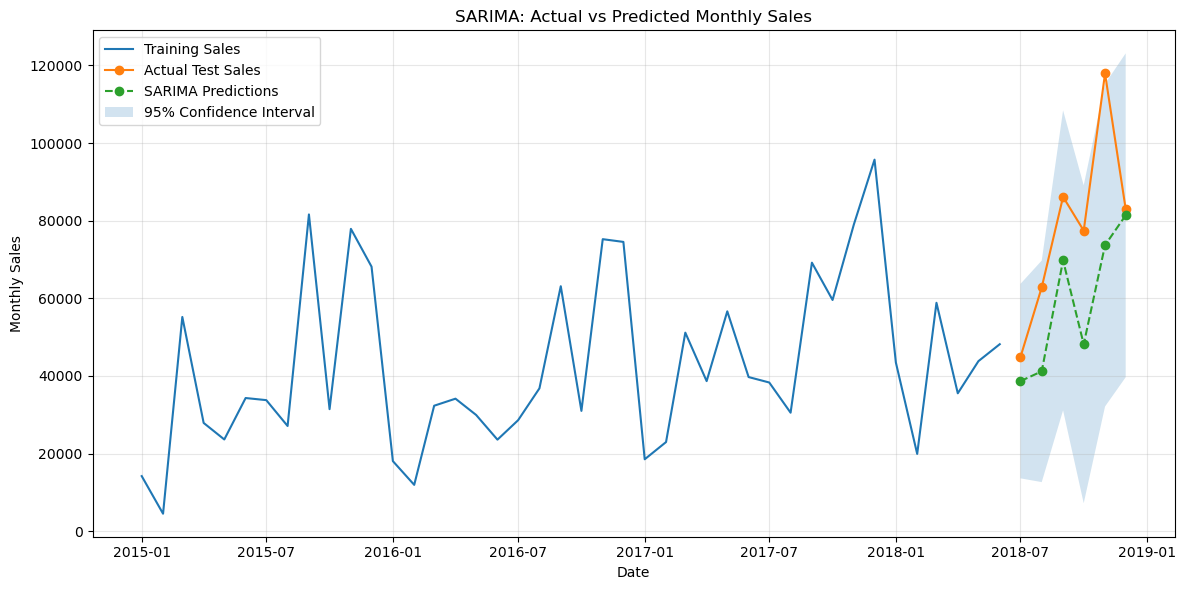

In [66]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    train_ts.index,
    train_ts.values,
    label="Training Sales"
)

plt.plot(
    test_ts.index,
    test_ts.values,
    marker="o",
    label="Actual Test Sales"
)

plt.plot(
    sarima_test_predictions.index,
    sarima_test_predictions.values,
    marker="o",
    linestyle="--",
    label="SARIMA Predictions"
)

plt.fill_between(
    sarima_test_confidence.index,
    sarima_test_confidence.iloc[:, 0],
    sarima_test_confidence.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA: Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/sarima_test_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
final_sarima_model = SARIMAX(
    monthly_ts,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima_model.fit(
    disp=False
)

In [68]:
sarima_future_result = (
    final_sarima_fit.get_forecast(steps=3)
)

sarima_future_forecast = (
    sarima_future_result.predicted_mean
)

sarima_future_confidence = (
    sarima_future_result.conf_int()
)

In [69]:
sarima_future_table = pd.DataFrame({
    "Forecasted Sales": sarima_future_forecast,
    "Lower Confidence Limit":
        sarima_future_confidence.iloc[:, 0],
    "Upper Confidence Limit":
        sarima_future_confidence.iloc[:, 1]
})

sarima_future_table.index.name = "Month"

display(sarima_future_table.round(2))

,Forecasted Sales,Lower Confidence Limit,Upper Confidence Limit
Month,,,
2019-01-01,55786.46,26637.50,84935.42
2019-02-01,9717.74,-22462.70,41898.18
2019-03-01,49130.95,6123.99,92137.91


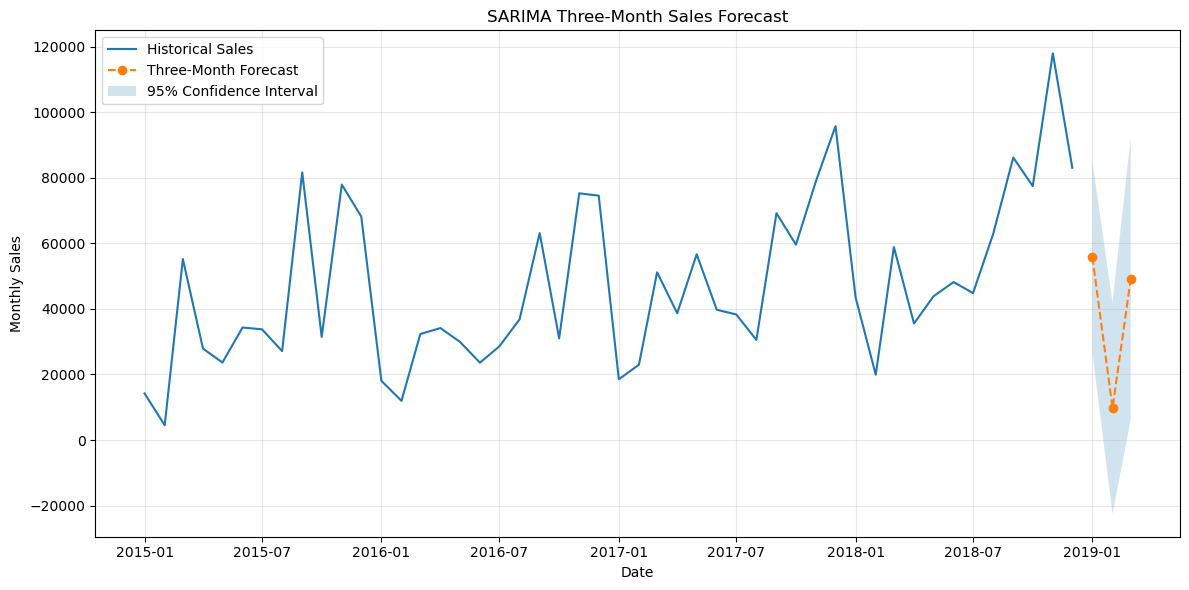

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    label="Historical Sales"
)

plt.plot(
    sarima_future_forecast.index,
    sarima_future_forecast.values,
    marker="o",
    linestyle="--",
    label="Three-Month Forecast"
)

plt.fill_between(
    sarima_future_confidence.index,
    sarima_future_confidence.iloc[:, 0],
    sarima_future_confidence.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Three-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/sarima_future_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
sarima_test_comparison.to_csv(
    "sarima_test_predictions.csv"
)

sarima_future_table.to_csv(
    "sarima_future_forecast.csv"
)

print("SARIMA results saved successfully.")

SARIMA results saved successfully.


In [72]:
# SARIMA Model Interpretation

#The selected model was SARIMA (1,0,2) × (0,1,1,12), with an AIC value
#of 331.37. The non-seasonal differencing value was set to zero because
#the original monthly series was found to be stationary. However, one
#seasonal difference was included to capture the recurring annual sales
#cycle.

#On the six-month test period, the model achieved an MAE of 19,882.14,
#an RMSE of 24,461.21 and a MAPE of 24.07%. The model captured the general
#increase in sales toward the end of the year but underestimated the size
#of the September, October and November sales peaks. The November forecast
#showed the largest error.

#The December prediction was close to the actual value, indicating that
#the model captured part of the recurring annual seasonality. However,
#the wide confidence intervals and near-singular covariance warning
#suggest that the model estimates may be unstable because only 42 monthly
#observations were available for training.

#Therefore, the SARIMA model should not yet be selected for production.
#Its performance must be compared with Prophet and XGBoost using the same
#test period and evaluation metrics.

In [73]:
sarima_future_business = sarima_future_table.copy()

sarima_future_business[
    "Business Lower Confidence Limit"
] = (
    sarima_future_business[
        "Lower Confidence Limit"
    ].clip(lower=0)
)

display(
    sarima_future_business.round(2)
)

,Forecasted Sales,Lower Confidence Limit,Upper Confidence Limit,Business Lower Confidence Limit
Month,,,,
2019-01-01,55786.46,26637.50,84935.42,26637.50
2019-02-01,9717.74,-22462.70,41898.18,0.00
2019-03-01,49130.95,6123.99,92137.91,6123.99


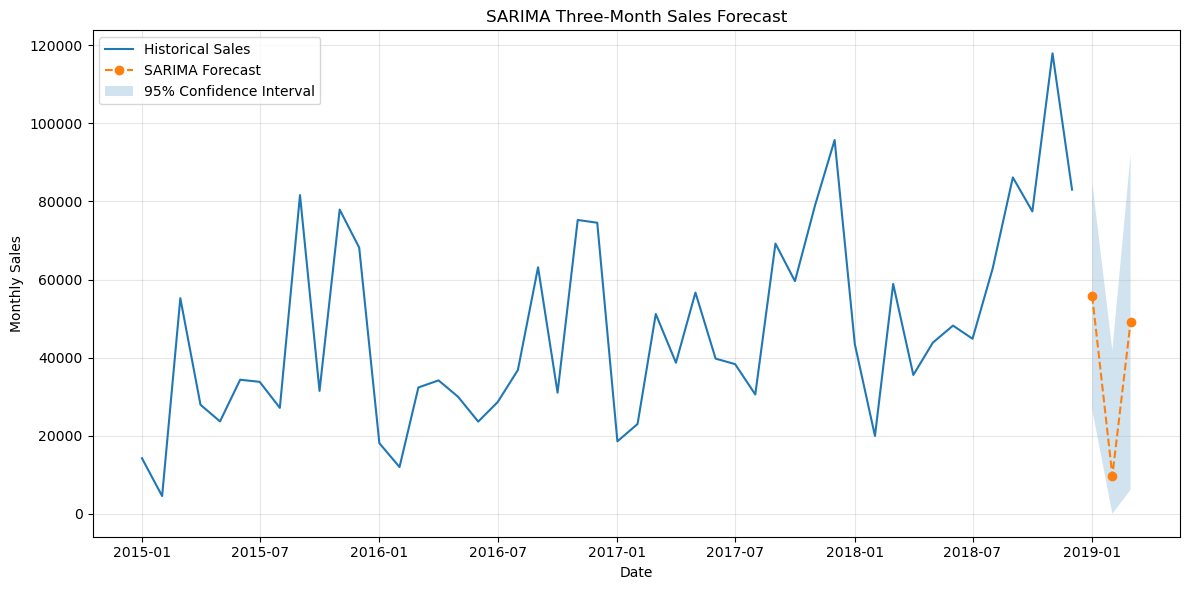

In [74]:
business_lower_bound = (
    sarima_future_confidence.iloc[:, 0]
    .clip(lower=0)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    label="Historical Sales"
)

plt.plot(
    sarima_future_forecast.index,
    sarima_future_forecast.values,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.fill_between(
    sarima_future_confidence.index,
    business_lower_bound,
    sarima_future_confidence.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Three-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
seasonal_naive_predictions = pd.Series(
    [
        monthly_ts.loc[
            date - pd.DateOffset(years=1)
        ]
        for date in test_ts.index
    ],
    index=test_ts.index,
    name="Seasonal Naive Prediction"
)

seasonal_naive_metrics = calculate_forecast_metrics(
    test_ts.values,
    seasonal_naive_predictions.values,
    "Seasonal Naive"
)

display(
    pd.DataFrame(
        [seasonal_naive_metrics]
    ).round(2)
)

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,20867.49,23680.58,26.15


In [76]:
baseline_comparison = pd.DataFrame([
    sarima_metrics,
    seasonal_naive_metrics
])

display(
    baseline_comparison.round(2)
)

,Model,MAE,RMSE,MAPE
0,SARIMA,19882.14,24461.21,24.07
1,Seasonal Naive,20867.49,23680.58,26.15


In [77]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [78]:
from prophet import Prophet

In [79]:
prophet_train_df = (
    train_ts
    .rename("y")
    .reset_index()
)

prophet_train_df.columns = ["ds", "y"]

display(prophet_train_df.head())
display(prophet_train_df.tail())

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


,ds,y
37,2018-02-01,19920.9974
38,2018-03-01,58863.4128
39,2018-04-01,35541.9101
40,2018-05-01,43825.9822
41,2018-06-01,48190.7277


In [80]:
print(prophet_train_df.dtypes)
print(prophet_train_df.shape)

ds    datetime64[ns]
y            float64
dtype: object
(42, 2)


In [81]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

prophet_model.fit(prophet_train_df)

19:37:12 - cmdstanpy - INFO - Chain [1] start processing
19:37:12 - cmdstanpy - INFO - Chain [1] done processing


In [82]:
prophet_test_dates = pd.DataFrame({
    "ds": test_ts.index
})

prophet_test_output = prophet_model.predict(
    prophet_test_dates
)

prophet_test_predictions = pd.Series(
    prophet_test_output["yhat"].values,
    index=test_ts.index,
    name="Prophet Prediction"
)

prophet_test_lower = pd.Series(
    prophet_test_output["yhat_lower"].values,
    index=test_ts.index
)

prophet_test_upper = pd.Series(
    prophet_test_output["yhat_upper"].values,
    index=test_ts.index
)

In [83]:
prophet_test_comparison = pd.DataFrame({
    "Actual Sales": test_ts,
    "Prophet Prediction":
        prophet_test_predictions,
    "Lower Confidence Limit":
        prophet_test_lower,
    "Upper Confidence Limit":
        prophet_test_upper
})

display(
    prophet_test_comparison.round(2)
)

,Actual Sales,Prophet Prediction,Lower Confidence Limit,Upper Confidence Limit
Order Date,,,,
2018-07-01,44825.10,44107.49,31900.42,55032.96
2018-08-01,62837.85,39286.26,27281.01,51699.34
2018-09-01,86152.89,85450.34,74052.79,96974.73
2018-10-01,77448.13,49818.28,37939.97,61091.01
2018-11-01,117938.16,88676.01,77653.65,100376.55
2018-12-01,83030.39,88174.04,77338.52,99746.55


In [84]:
prophet_metrics = calculate_forecast_metrics(
    test_ts.values,
    prophet_test_predictions.values,
    "Prophet"
)

display(
    pd.DataFrame(
        [prophet_metrics]
    ).round(2)
)

,Model,MAE,RMSE,MAPE
0,Prophet,14501.23,19156.48,17.76


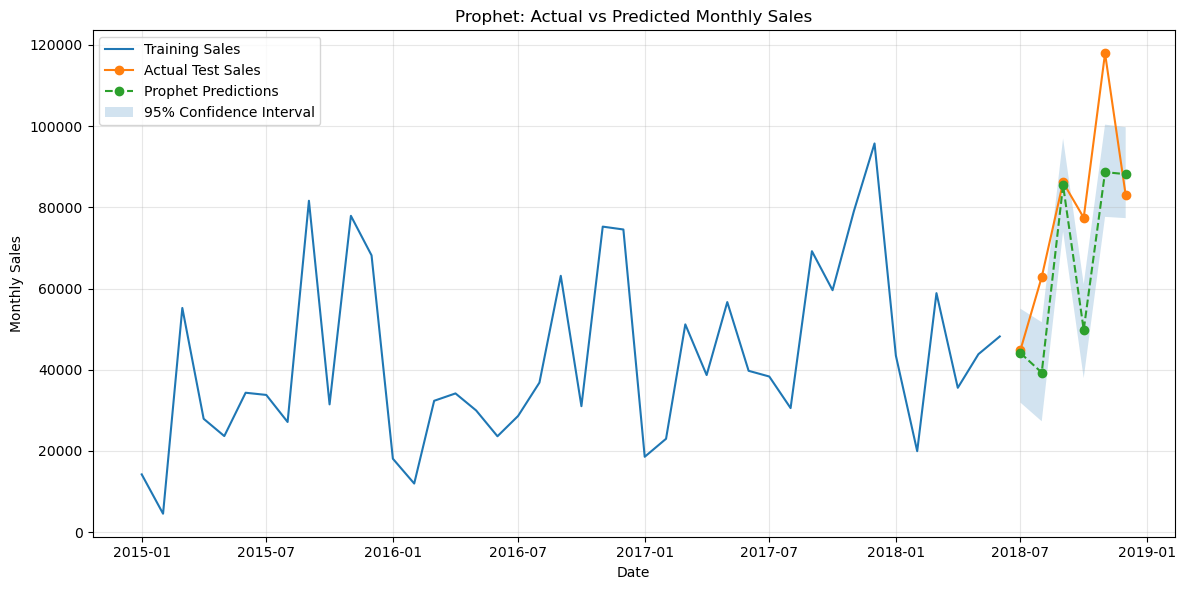

In [85]:
plt.figure(figsize=(12, 6))

plt.plot(
    train_ts.index,
    train_ts.values,
    label="Training Sales"
)

plt.plot(
    test_ts.index,
    test_ts.values,
    marker="o",
    label="Actual Test Sales"
)

plt.plot(
    prophet_test_predictions.index,
    prophet_test_predictions.values,
    marker="o",
    linestyle="--",
    label="Prophet Predictions"
)

plt.fill_between(
    test_ts.index,
    prophet_test_lower.clip(lower=0),
    prophet_test_upper,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Prophet: Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/prophet_test_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

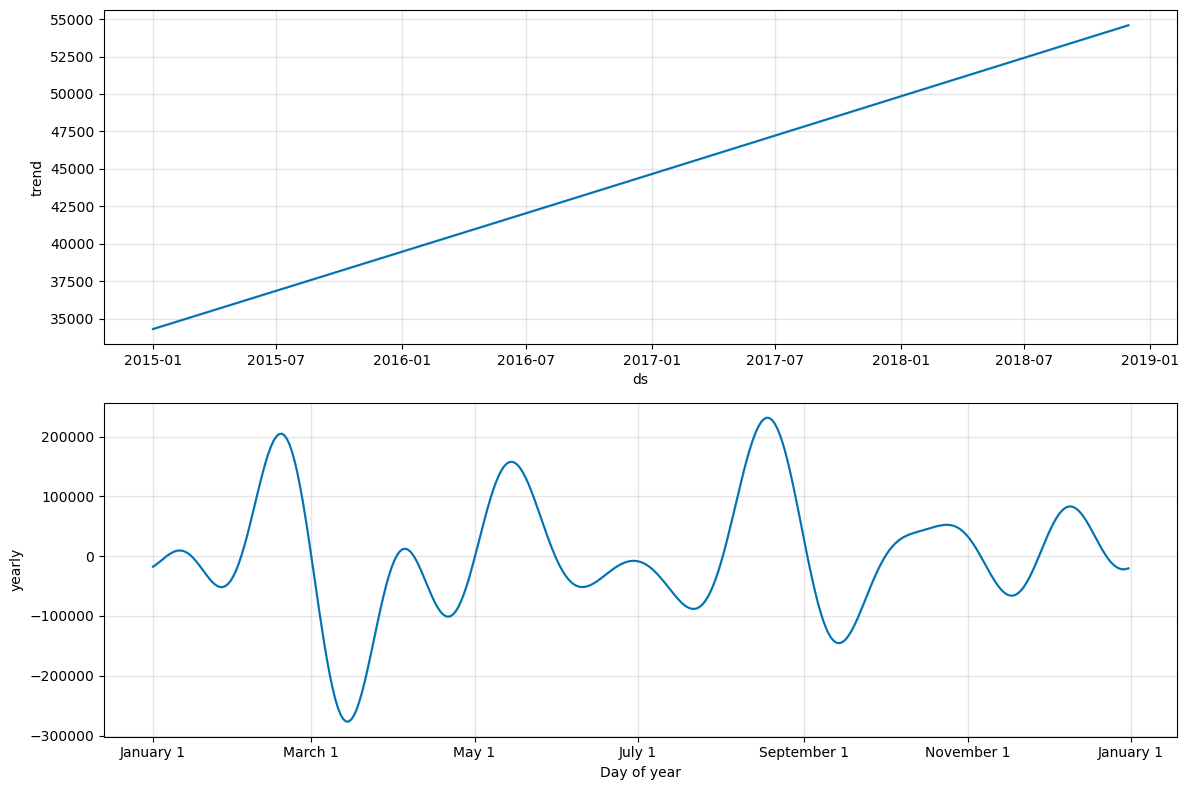

In [86]:
component_dates = pd.DataFrame({
    "ds": pd.date_range(
        start=train_ts.index.min(),
        end=test_ts.index.max(),
        freq="MS"
    )
})

prophet_component_forecast = (
    prophet_model.predict(component_dates)
)

component_figure = prophet_model.plot_components(
    prophet_component_forecast
)

component_figure.set_size_inches(12, 8)

plt.tight_layout()

plt.savefig(
    "charts/prophet_monthly_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
daily_ts_for_prophet = (
    superstore_df
    .set_index("Order Date")["Sales"]
    .resample("D")
    .sum()
    .asfreq("D", fill_value=0)
)

daily_prophet_df = (
    daily_ts_for_prophet
    .rename("y")
    .reset_index()
)

daily_prophet_df.columns = ["ds", "y"]

display(daily_prophet_df.head())

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [88]:
daily_component_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

daily_component_model.fit(
    daily_prophet_df
)

daily_component_output = (
    daily_component_model.predict(
        daily_prophet_df[["ds"]]
    )
)

19:37:15 - cmdstanpy - INFO - Chain [1] start processing
19:37:15 - cmdstanpy - INFO - Chain [1] done processing


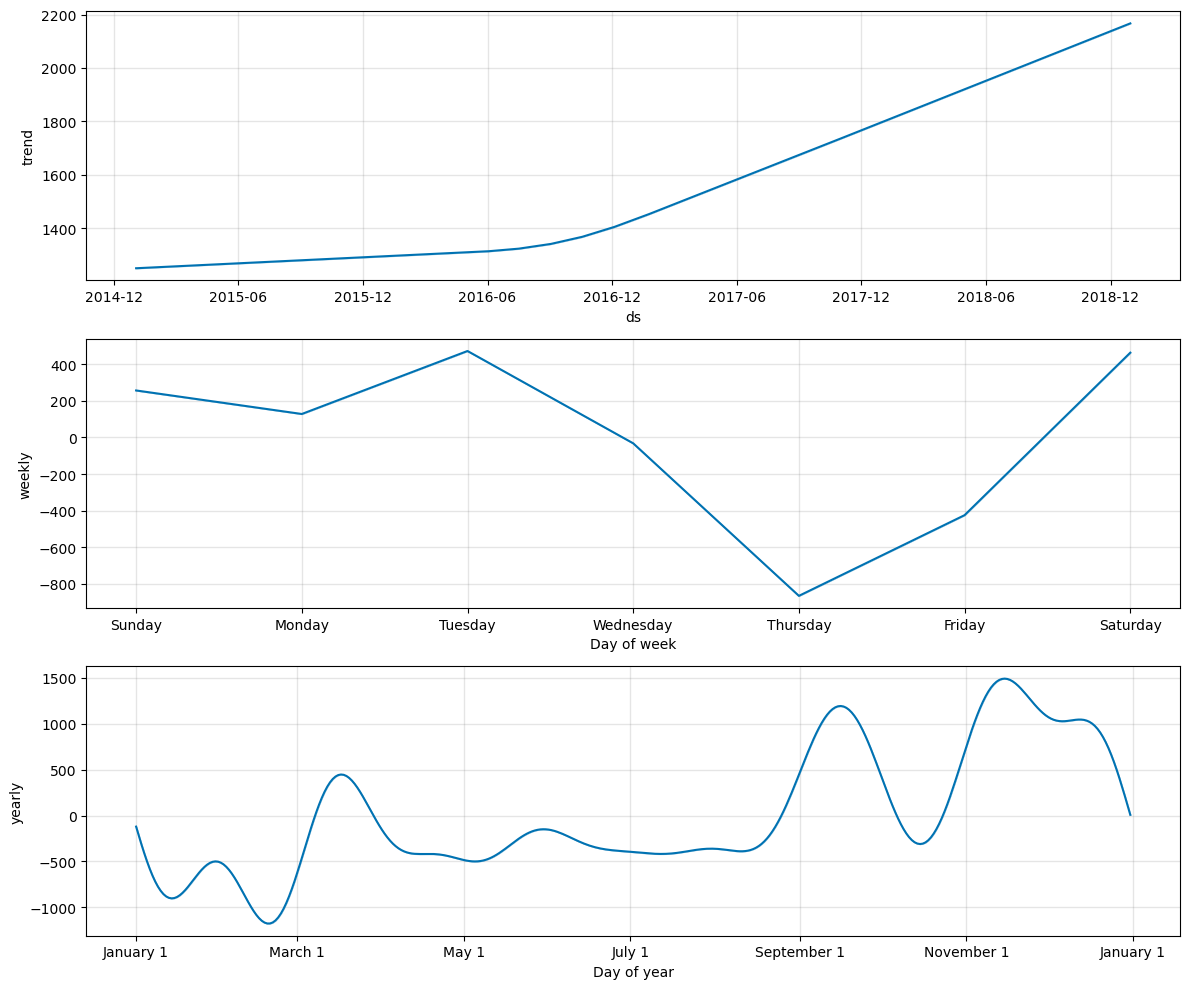

In [89]:
daily_component_figure = (
    daily_component_model.plot_components(
        daily_component_output
    )
)

daily_component_figure.set_size_inches(
    12,
    10
)

plt.tight_layout()

plt.savefig(
    "charts/prophet_weekly_yearly_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
#The primary Prophet forecasting model used monthly sales data and therefore
#disabled weekly seasonality. Weekly patterns cannot be reliably estimated
#after sales have been aggregated to one observation per month.

#To satisfy the seasonal behaviour analysis, a separate Prophet model was
#fitted to daily aggregated sales. This daily model was used only to examine
#weekly and yearly components and was not included in the monthly model
#comparison.

In [91]:
prophet_full_df = (
    monthly_ts
    .rename("y")
    .reset_index()
)

prophet_full_df.columns = ["ds", "y"]

In [92]:
final_prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

final_prophet_model.fit(
    prophet_full_df
)

19:37:17 - cmdstanpy - INFO - Chain [1] start processing
19:37:17 - cmdstanpy - INFO - Chain [1] done processing


In [93]:
prophet_future_dates = pd.DataFrame({
    "ds": pd.date_range(
        start=monthly_ts.index.max()
              + pd.offsets.MonthBegin(1),
        periods=3,
        freq="MS"
    )
})

prophet_future_output = (
    final_prophet_model.predict(
        prophet_future_dates
    )
)

In [94]:
prophet_future_table = (
    prophet_future_output[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ]
    .rename(
        columns={
            "ds": "Month",
            "yhat": "Forecasted Sales",
            "yhat_lower":
                "Lower Confidence Limit",
            "yhat_upper":
                "Upper Confidence Limit"
        }
    )
)

prophet_future_table[
    "Business Lower Confidence Limit"
] = (
    prophet_future_table[
        "Lower Confidence Limit"
    ].clip(lower=0)
)

display(
    prophet_future_table.round(2)
)

,Month,Forecasted Sales,Lower Confidence Limit,Upper Confidence Limit,Business Lower Confidence Limit
0,2019-01-01,42548.14,27609.73,56552.03,27609.73
1,2019-02-01,33310.13,18456.61,48109.48,18456.61
2,2019-03-01,80304.67,65838.22,93969.41,65838.22


In [95]:
prophet_test_comparison.to_csv(
    "prophet_test_predictions.csv"
)

prophet_future_table.to_csv(
    "prophet_future_forecast.csv",
    index=False
)

print("Prophet results saved successfully.")

Prophet results saved successfully.


In [96]:
from prophet import Prophet

regularized_prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5,
    interval_width=0.95
)

regularized_prophet_model.add_seasonality(
    name="yearly",
    period=365.25,
    fourier_order=4
)

regularized_prophet_model.fit(prophet_train_df)

regularized_output = regularized_prophet_model.predict(
    prophet_test_dates
)

regularized_predictions = pd.Series(
    regularized_output["yhat"].values,
    index=test_ts.index
)

regularized_metrics = calculate_forecast_metrics(
    test_ts.values,
    regularized_predictions.values,
    "Regularized Prophet"
)

display(
    pd.DataFrame([
        prophet_metrics,
        regularized_metrics
    ]).round(2)
)

19:37:18 - cmdstanpy - INFO - Chain [1] start processing
19:37:18 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE
0,Prophet,14501.23,19156.48,17.76
1,Regularized Prophet,16671.94,18918.37,20.69


In [97]:
# Prophet Model Findings

#The Prophet model achieved an MAE of 14,501.23, an RMSE of 19,156.48
#and a MAPE of 17.76%. It performed better than SARIMA across all three
#evaluation metrics.

#The model closely predicted July, September and December sales. However,
#it underestimated demand in August, October and November, particularly
#during the November peak. This indicates that Prophet captured the
#seasonal direction but could not fully reproduce unusually large sales
#spikes.

#The weekly component from the daily-data model suggests stronger sales
#effects on Tuesday and Saturday, while Thursday showed the weakest effect.
#These patterns may partly reflect order-recording behaviour and should
#not automatically be interpreted as customer demand.

#The yearly component confirms stronger demand during September and the
#November–December period. January and February showed comparatively weak
#seasonal demand.

#The three-month forecast predicts sales of 42,548.14 in January,
#33,310.13 in February and 80,304.67 in March. This suggests that inventory
#requirements may decrease in February before increasing considerably in
#March.

In [98]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

In [100]:
def get_season_number(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Autumn

In [101]:
def create_xgboost_features(series):
    df = series.rename("Sales").to_frame()

    df["Lag_1"] = df["Sales"].shift(1)
    df["Lag_2"] = df["Sales"].shift(2)
    df["Lag_3"] = df["Sales"].shift(3)

    df["Rolling_Mean_3"] = (
        df["Sales"]
        .shift(1)
        .rolling(window=3)
        .mean()
    )

    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    df["Season"] = [
        get_season_number(month)
        for month in df.index.month
    ]

    return df.dropna()

In [102]:
xgb_dataset = create_xgboost_features(monthly_ts)

display(xgb_dataset.head())
print("XGBoost dataset shape:", xgb_dataset.shape)

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,2
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,2
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,3
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,3
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,3


XGBoost dataset shape: (45, 8)


In [103]:
feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

xgb_train_df = xgb_dataset[
    xgb_dataset.index < test_ts.index.min()
]

X_train_xgb = xgb_train_df[feature_columns]
y_train_xgb = xgb_train_df["Sales"]

print("Training rows:", len(X_train_xgb))

Training rows: 39


In [104]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [105]:
def recursive_xgboost_forecast(
    model,
    history_series,
    forecast_dates,
    feature_columns
):
    history = list(
        history_series.astype(float).values
    )

    predictions = []

    for date in forecast_dates:
        lag_1 = history[-1]
        lag_2 = history[-2]
        lag_3 = history[-3]

        rolling_mean_3 = np.mean(
            history[-3:]
        )

        feature_row = pd.DataFrame(
            [{
                "Lag_1": lag_1,
                "Lag_2": lag_2,
                "Lag_3": lag_3,
                "Rolling_Mean_3": rolling_mean_3,
                "Month": date.month,
                "Quarter": date.quarter,
                "Season": get_season_number(
                    date.month
                )
            }],
            index=[date]
        )

        feature_row = feature_row[
            feature_columns
        ]

        prediction = float(
            model.predict(feature_row)[0]
        )

        prediction = max(prediction, 0)

        predictions.append(prediction)
        history.append(prediction)

    return pd.Series(
        predictions,
        index=forecast_dates,
        name="XGBoost Prediction"
    )

In [106]:
xgb_test_predictions = recursive_xgboost_forecast(
    model=xgb_model,
    history_series=train_ts,
    forecast_dates=test_ts.index,
    feature_columns=feature_columns
)

In [107]:
xgb_test_comparison = pd.DataFrame({
    "Actual Sales": test_ts,
    "XGBoost Prediction":
        xgb_test_predictions
})

display(
    xgb_test_comparison.round(2)
)

,Actual Sales,XGBoost Prediction
Order Date,,
2018-07-01,44825.10,43506.22
2018-08-01,62837.85,43387.07
2018-09-01,86152.89,70063.18
2018-10-01,77448.13,58947.41
2018-11-01,117938.16,80216.88
2018-12-01,83030.39,83799.91


In [108]:
xgb_metrics = calculate_forecast_metrics(
    test_ts.values,
    xgb_test_predictions.values,
    "XGBoost"
)

display(
    pd.DataFrame(
        [xgb_metrics]
    ).round(2)
)

,Model,MAE,RMSE,MAPE
0,XGBoost,15641.82,20019.64,18.23


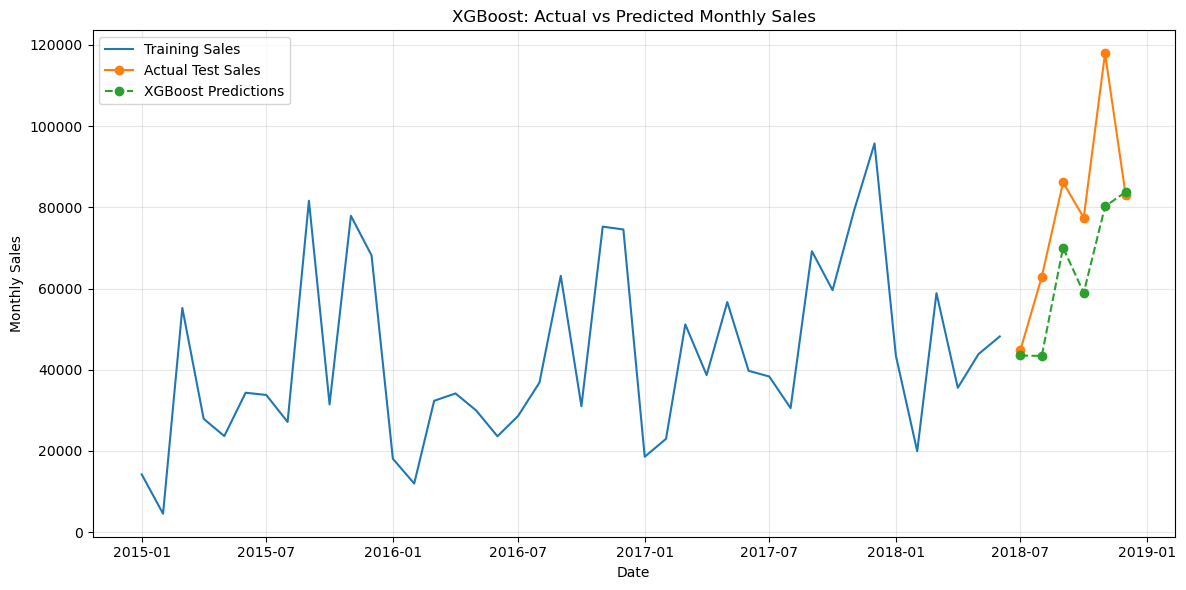

In [109]:
plt.figure(figsize=(12, 6))

plt.plot(
    train_ts.index,
    train_ts.values,
    label="Training Sales"
)

plt.plot(
    test_ts.index,
    test_ts.values,
    marker="o",
    label="Actual Test Sales"
)

plt.plot(
    xgb_test_predictions.index,
    xgb_test_predictions.values,
    marker="o",
    linestyle="--",
    label="XGBoost Predictions"
)

plt.title("XGBoost: Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/xgboost_test_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance":
        xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.round(4)
)

,Feature,Importance
5,Quarter,0.4352
4,Month,0.2465
6,Season,0.1651
1,Lag_2,0.0433
0,Lag_1,0.0409
2,Lag_3,0.0358
3,Rolling_Mean_3,0.0333


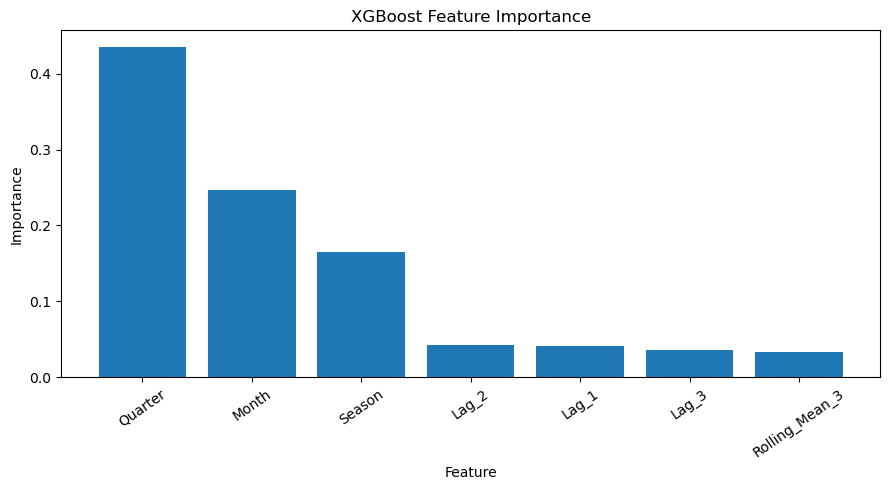

In [111]:
plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=35)
plt.tight_layout()

plt.savefig(
    "charts/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
final_xgb_dataset = create_xgboost_features(
    monthly_ts
)

final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42
)

final_xgb_model.fit(
    final_xgb_dataset[feature_columns],
    final_xgb_dataset["Sales"]
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [113]:
xgb_future_dates = pd.date_range(
    start=monthly_ts.index.max()
          + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

xgb_future_forecast = (
    recursive_xgboost_forecast(
        model=final_xgb_model,
        history_series=monthly_ts,
        forecast_dates=xgb_future_dates,
        feature_columns=feature_columns
    )
)

xgb_future_table = pd.DataFrame({
    "Forecasted Sales":
        xgb_future_forecast
})

xgb_future_table.index.name = "Month"

display(
    xgb_future_table.round(2)
)

,Forecasted Sales
Month,
2019-01-01,38503.32
2019-02-01,34721.69
2019-03-01,41940.64


In [114]:
model_comparison = pd.DataFrame([
    {
        **sarima_metrics,
        "Forecast Month 1":
            sarima_future_forecast.iloc[0],
        "Forecast Month 2":
            sarima_future_forecast.iloc[1],
        "Forecast Month 3":
            sarima_future_forecast.iloc[2]
    },
    {
        **prophet_metrics,
        "Forecast Month 1":
            prophet_future_table[
                "Forecasted Sales"
            ].iloc[0],
        "Forecast Month 2":
            prophet_future_table[
                "Forecasted Sales"
            ].iloc[1],
        "Forecast Month 3":
            prophet_future_table[
                "Forecasted Sales"
            ].iloc[2]
    },
    {
        **xgb_metrics,
        "Forecast Month 1":
            xgb_future_forecast.iloc[0],
        "Forecast Month 2":
            xgb_future_forecast.iloc[1],
        "Forecast Month 3":
            xgb_future_forecast.iloc[2]
    }
])

model_comparison = model_comparison.sort_values(
    "RMSE"
)

display(
    model_comparison.round(2)
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
1,Prophet,14501.23,19156.48,17.76,42548.14,33310.13,80304.67
2,XGBoost,15641.82,20019.64,18.23,38503.32,34721.69,41940.64
0,SARIMA,19882.14,24461.21,24.07,55786.46,9717.74,49130.95


In [115]:
#Final Model Comparison and Recommendation

#The Prophet model achieved the best performance across all three evaluation
#metrics. It recorded an MAE of 14,501.23, an RMSE of 19,156.48 and a MAPE
#of 17.76%.

#XGBoost ranked second, with an MAE of 15,641.82, an RMSE of 20,019.64 and
#a MAPE of 18.23%. SARIMA produced the highest errors, with a MAPE of
#24.07%.

#Compared with SARIMA, Prophet reduced MAE by approximately 27.06%, RMSE by
#21.69% and MAPE by 26.22%. Prophet also performed slightly better than
#XGBoost across all three metrics.

#Therefore, Prophet is recommended as the best model among the three tested
#approaches. It captured recurring seasonal demand more effectively and
#produced the lowest forecasting errors.

#However, this recommendation is based on a six-month test period and only
#four years of monthly observations. The model should be retrained and
#evaluated regularly when new sales data becomes available.

In [116]:
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [117]:
def forecast_segment_with_prophet(
    filtered_df,
    segment_name,
    forecast_months=3
):
    """
    Aggregate a filtered segment to monthly sales,
    fit Prophet and forecast future monthly sales.
    """

    segment_monthly = (
        filtered_df
        .set_index("Order Date")["Sales"]
        .resample("MS")
        .sum()
        .asfreq("MS", fill_value=0)
        .astype(float)
    )

    prophet_data = (
        segment_monthly
        .rename_axis("ds")
        .reset_index(name="y")
    )

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        interval_width=0.95
    )

    model.fit(prophet_data)

    future_dates = pd.DataFrame({
        "ds": pd.date_range(
            start=segment_monthly.index.max()
                  + pd.offsets.MonthBegin(1),
            periods=forecast_months,
            freq="MS"
        )
    })

    forecast = model.predict(future_dates)

    result = forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    result.rename(
        columns={
            "ds": "Month",
            "yhat": "Forecasted Sales",
            "yhat_lower": "Lower Confidence Limit",
            "yhat_upper": "Upper Confidence Limit"
        },
        inplace=True
    )

    result["Forecasted Sales"] = (
        result["Forecasted Sales"].clip(lower=0)
    )

    result["Lower Confidence Limit"] = (
        result["Lower Confidence Limit"].clip(lower=0)
    )

    result["Segment"] = segment_name

    return result, model, segment_monthly

In [118]:
segment_datasets = {
    "Furniture": superstore_df[
        superstore_df["Category"] == "Furniture"
    ],

    "Technology": superstore_df[
        superstore_df["Category"] == "Technology"
    ],

    "Office Supplies": superstore_df[
        superstore_df["Category"] == "Office Supplies"
    ],

    "West Region": superstore_df[
        superstore_df["Region"] == "West"
    ],

    "East Region": superstore_df[
        superstore_df["Region"] == "East"
    ]
}

In [119]:
for segment_name, segment_df in segment_datasets.items():
    print(
        segment_name,
        "rows:",
        len(segment_df),
        "| total sales:",
        round(segment_df["Sales"].sum(), 2)
    )

Furniture rows: 2078 | total sales: 728658.58
Technology rows: 1813 | total sales: 827455.87
Office Supplies rows: 5909 | total sales: 705422.33
West Region rows: 3140 | total sales: 710219.68
East Region rows: 2785 | total sales: 669518.73


In [120]:
segment_forecasts = []
segment_models = {}
segment_history = {}

for segment_name, segment_df in segment_datasets.items():

    forecast_result, model, history = (
        forecast_segment_with_prophet(
            filtered_df=segment_df,
            segment_name=segment_name,
            forecast_months=3
        )
    )

    segment_forecasts.append(forecast_result)
    segment_models[segment_name] = model
    segment_history[segment_name] = history

19:37:24 - cmdstanpy - INFO - Chain [1] start processing
19:37:24 - cmdstanpy - INFO - Chain [1] done processing
19:37:24 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing
19:37:26 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing


In [121]:
all_segment_forecasts = pd.concat(
    segment_forecasts,
    ignore_index=True
)

display(
    all_segment_forecasts.round(2)
)

,Month,Forecasted Sales,Lower Confidence Limit,Upper Confidence Limit,Segment
0,2019-01-01,12703.03,8063.27,17210.29,Furniture
1,2019-02-01,7686.98,3178.00,12571.84,Furniture
2,2019-03-01,16989.05,12438.70,21351.67,Furniture
3,2019-01-01,13815.85,4496.16,22445.91,Technology
4,2019-02-01,11356.81,1989.44,20496.62,Technology
5,2019-03-01,42215.82,33754.37,51264.25,Technology
6,2019-01-01,14508.93,6517.17,22686.88,Office Supplies
7,2019-02-01,12500.10,3960.58,20620.66,Office Supplies
8,2019-03-01,19421.52,10653.10,27419.44,Office Supplies
9,2019-01-01,14626.05,9392.72,20164.18,West Region


In [122]:
segment_forecast_pivot = (
    all_segment_forecasts
    .pivot(
        index="Month",
        columns="Segment",
        values="Forecasted Sales"
    )
)

display(
    segment_forecast_pivot.round(2)
)

Segment,East Region,Furniture,Office Supplies,Technology,West Region
Month,,,,,
2019-01-01,9412.42,12703.03,14508.93,13815.85,14626.05
2019-02-01,10128.31,7686.98,12500.10,11356.81,11907.97
2019-03-01,14478.01,16989.05,19421.52,42215.82,26432.59


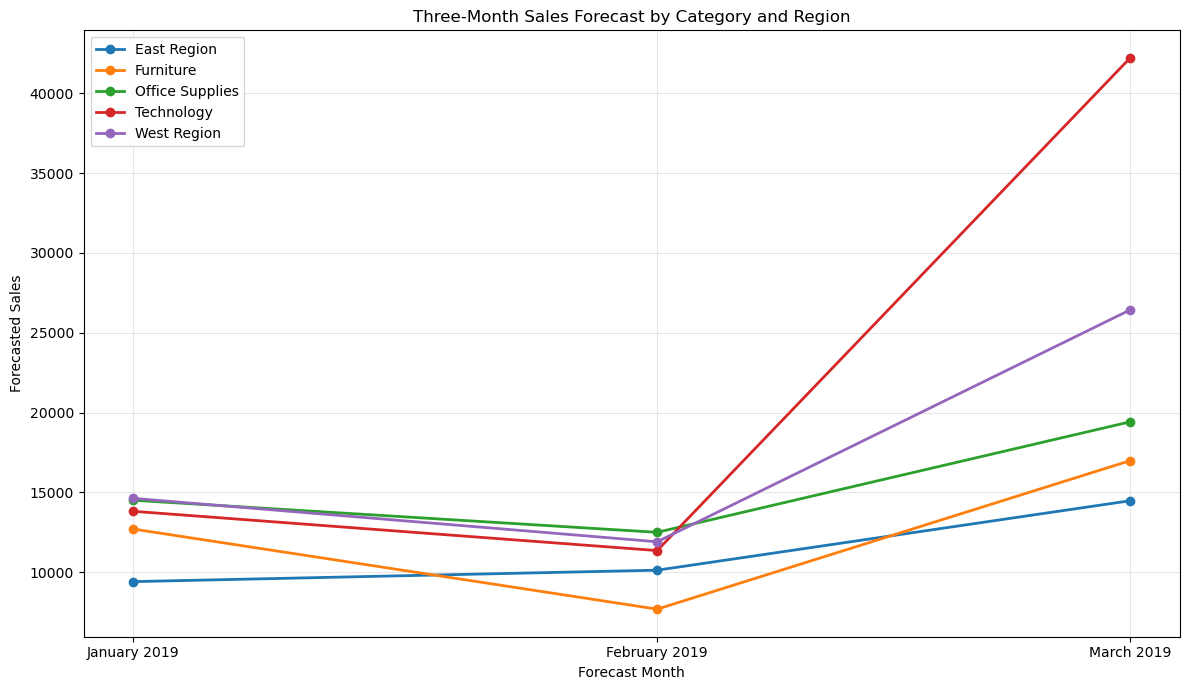

In [123]:
plt.figure(figsize=(12, 7))

for column in segment_forecast_pivot.columns:
    plt.plot(
        segment_forecast_pivot.index,
        segment_forecast_pivot[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title(
    "Three-Month Sales Forecast by Category and Region"
)
plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Sales")
plt.xticks(
    segment_forecast_pivot.index,
    [
        date.strftime("%B %Y")
        for date in segment_forecast_pivot.index
    ]
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/category_region_forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
segment_growth_summary = []

for segment in segment_forecast_pivot.columns:

    month_1 = segment_forecast_pivot[
        segment
    ].iloc[0]

    month_2 = segment_forecast_pivot[
        segment
    ].iloc[1]

    month_3 = segment_forecast_pivot[
        segment
    ].iloc[2]

    absolute_growth = month_3 - month_1

    if month_1 != 0:
        growth_percentage = (
            absolute_growth / month_1
        ) * 100
    else:
        growth_percentage = np.nan

    segment_growth_summary.append({
        "Segment": segment,
        "Month 1 Forecast": month_1,
        "Month 2 Forecast": month_2,
        "Month 3 Forecast": month_3,
        "Absolute Growth": absolute_growth,
        "Growth Percentage": growth_percentage
    })

In [125]:
segment_growth_df = pd.DataFrame(
    segment_growth_summary
).sort_values(
    "Growth Percentage",
    ascending=False
)

display(
    segment_growth_df.round(2)
)

,Segment,Month 1 Forecast,Month 2 Forecast,Month 3 Forecast,Absolute Growth,Growth Percentage
3,Technology,13815.85,11356.81,42215.82,28399.98,205.56
4,West Region,14626.05,11907.97,26432.59,11806.53,80.72
0,East Region,9412.42,10128.31,14478.01,5065.58,53.82
2,Office Supplies,14508.93,12500.10,19421.52,4912.59,33.86
1,Furniture,12703.03,7686.98,16989.05,4286.02,33.74


In [126]:
category_names = [
    "Furniture",
    "Technology",
    "Office Supplies"
]

region_names = [
    "West Region",
    "East Region"
]

In [127]:
category_growth = (
    segment_growth_df[
        segment_growth_df["Segment"]
        .isin(category_names)
    ]
    .sort_values(
        "Growth Percentage",
        ascending=False
    )
)

region_growth = (
    segment_growth_df[
        segment_growth_df["Segment"]
        .isin(region_names)
    ]
    .sort_values(
        "Growth Percentage",
        ascending=False
    )
)

In [128]:
strongest_category = category_growth.iloc[0]
strongest_region = region_growth.iloc[0]

print(
    "Strongest upcoming category growth:",
    strongest_category["Segment"]
)

print(
    "Category growth percentage:",
    round(
        strongest_category[
            "Growth Percentage"
        ],
        2
    ),
    "%"
)

print(
    "\nStrongest upcoming region growth:",
    strongest_region["Segment"]
)

print(
    "Region growth percentage:",
    round(
        strongest_region[
            "Growth Percentage"
        ],
        2
    ),
    "%"
)

Strongest upcoming category growth: Technology
Category growth percentage: 205.56 %

Strongest upcoming region growth: West Region
Region growth percentage: 80.72 %


In [129]:
all_segment_forecasts.to_csv(
    "outputs/category_region_forecasts.csv",
    index=False
)

segment_growth_df.to_csv(
    "outputs/category_region_growth_summary.csv",
    index=False
)

print("Task 4 forecast outputs saved successfully.")

Task 4 forecast outputs saved successfully.


In [130]:
#Category and Region Forecast Findings
#The Prophet model was fitted separately to Furniture, Technology, Office
#Supplies, West region and East region sales.

#Technology showed the strongest forecast growth among the product
#categories. Its forecast increased from 13,815.85 in January 2019 to
#42,215.82 in March 2019, representing growth of 205.56%. This result
#suggests a strong seasonal increase in Technology demand during March.

#However, the Technology forecast also had a relatively wide confidence
#range. Therefore, the exact growth percentage should be treated as an
#estimate rather than a guaranteed increase. Inventory should be increased
#gradually while actual orders are monitored.

#Among the regions, the West showed the strongest expected growth. Sales
#were forecast to increase from 14,626.05 in January to 26,432.59 in March,
#representing growth of 80.72%.

#Furniture demand was expected to decline in February before recovering in
#March. Office Supplies showed moderate growth, while the East region
#showed steady but lower growth than the West.

#Based on these results, Technology products should receive the highest
#inventory attention, while distribution capacity in the West region
#should be reviewed before the expected March increase.

In [131]:
from sklearn.ensemble import IsolationForest

os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

anomaly_df = weekly_sales.copy()

anomaly_df["Week"] = pd.to_datetime(
    anomaly_df["Week"]
)

anomaly_df = (
    anomaly_df
    .sort_values("Week")
    .reset_index(drop=True)
)

display(anomaly_df.head())
print("Number of weekly observations:", len(anomaly_df))

,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Number of weekly observations: 209


In [132]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

anomaly_df["Isolation Label"] = (
    isolation_model.fit_predict(
        anomaly_df[["Weekly Sales"]]
    )
)

anomaly_df["Isolation Score"] = (
    isolation_model.decision_function(
        anomaly_df[["Weekly Sales"]]
    )
)

anomaly_df["Isolation Anomaly"] = (
    anomaly_df["Isolation Label"] == -1
)

In [133]:
weekly_median = anomaly_df["Weekly Sales"].median()

anomaly_df["Isolation Type"] = np.where(
    anomaly_df["Isolation Anomaly"],
    np.where(
        anomaly_df["Weekly Sales"] >= weekly_median,
        "Unusually High",
        "Unusually Low"
    ),
    "Normal"
)

In [134]:
isolation_anomalies = anomaly_df[
    anomaly_df["Isolation Anomaly"]
].copy()

isolation_anomalies = (
    isolation_anomalies
    .sort_values("Weekly Sales", ascending=False)
)

display(
    isolation_anomalies[
        [
            "Week",
            "Weekly Sales",
            "Isolation Score",
            "Isolation Type"
        ]
    ].round(2)
)

print(
    "Isolation Forest anomalies:",
    len(isolation_anomalies)
)

,Week,Weekly Sales,Isolation Score,Isolation Type
11,2015-03-22,37703.66,-0.20,Unusually High
204,2018-12-02,35998.90,-0.17,Unusually High
202,2018-11-18,30572.45,-0.08,Unusually High
36,2015-09-13,29959.14,-0.05,Unusually High
200,2018-11-04,29017.47,-0.02,Unusually High
154,2017-12-17,25449.80,-0.00,Unusually High
28,2015-07-19,1387.69,-0.01,Unusually Low
5,2015-02-08,968.53,-0.04,Unusually Low
55,2016-01-24,358.52,-0.04,Unusually Low
0,2015-01-04,304.51,-0.03,Unusually Low


Isolation Forest anomalies: 11


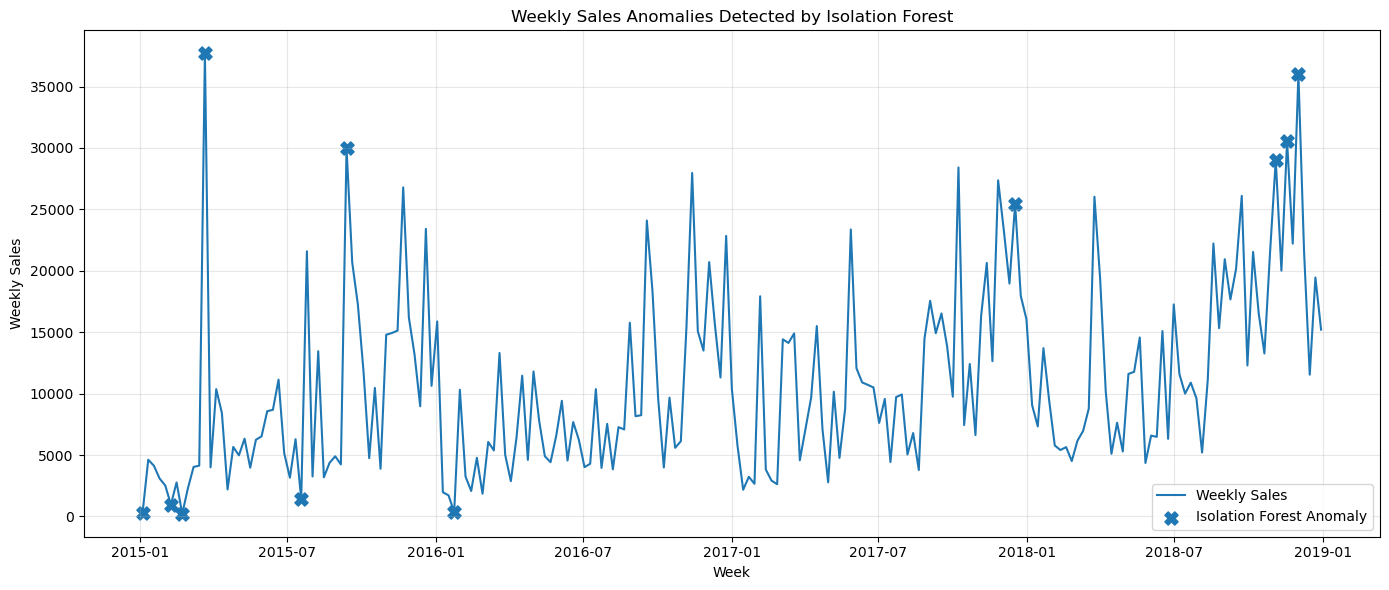

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["Week"],
    anomaly_df["Weekly Sales"],
    label="Weekly Sales"
)

plt.scatter(
    isolation_anomalies["Week"],
    isolation_anomalies["Weekly Sales"],
    marker="X",
    s=90,
    label="Isolation Forest Anomaly"
)

plt.title("Weekly Sales Anomalies Detected by Isolation Forest")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [136]:
rolling_window = 8

anomaly_df["Rolling Mean"] = (
    anomaly_df["Weekly Sales"]
    .shift(1)
    .rolling(window=rolling_window)
    .mean()
)

anomaly_df["Rolling Std"] = (
    anomaly_df["Weekly Sales"]
    .shift(1)
    .rolling(window=rolling_window)
    .std()
)

In [137]:
anomaly_df["Rolling Z Score"] = (
    anomaly_df["Weekly Sales"] -
    anomaly_df["Rolling Mean"]
) / anomaly_df["Rolling Std"]

In [138]:
anomaly_df["ZScore Anomaly"] = (
    anomaly_df["Rolling Z Score"].abs() > 2
)

anomaly_df["ZScore Type"] = np.where(
    anomaly_df["Rolling Z Score"] > 2,
    "Unusually High",
    np.where(
        anomaly_df["Rolling Z Score"] < -2,
        "Unusually Low",
        "Normal"
    )
)

In [139]:
zscore_anomalies = anomaly_df[
    anomaly_df["ZScore Anomaly"]
].copy()

display(
    zscore_anomalies[
        [
            "Week",
            "Weekly Sales",
            "Rolling Mean",
            "Rolling Std",
            "Rolling Z Score",
            "ZScore Type"
        ]
    ].round(2)
)

print(
    "Rolling Z-Score anomalies:",
    len(zscore_anomalies)
)

,Week,Weekly Sales,Rolling Mean,Rolling Std,Rolling Z Score,ZScore Type
11,2015-03-22,37703.66,2505.62,1363.93,25.81,Unusually High
24,2015-06-21,11139.44,6369.21,1623.62,2.94,Unusually High
28,2015-07-19,1387.69,6968.86,2447.54,-2.28,Unusually Low
29,2015-07-26,21590.08,6362.07,3153.43,4.83,Unusually High
36,2015-09-13,29959.14,7047.34,6902.80,3.32,Unusually High
46,2015-11-22,26793.62,11624.14,4978.15,3.05,Unusually High
53,2016-01-10,1973.44,16275.29,6069.14,-2.36,Unusually Low
63,2016-03-20,13310.14,4258.29,3122.57,2.90,Unusually High
80,2016-07-17,10366.16,5896.89,1937.52,2.31,Unusually High
86,2016-08-28,15773.48,6045.49,2388.46,4.07,Unusually High


Rolling Z-Score anomalies: 22


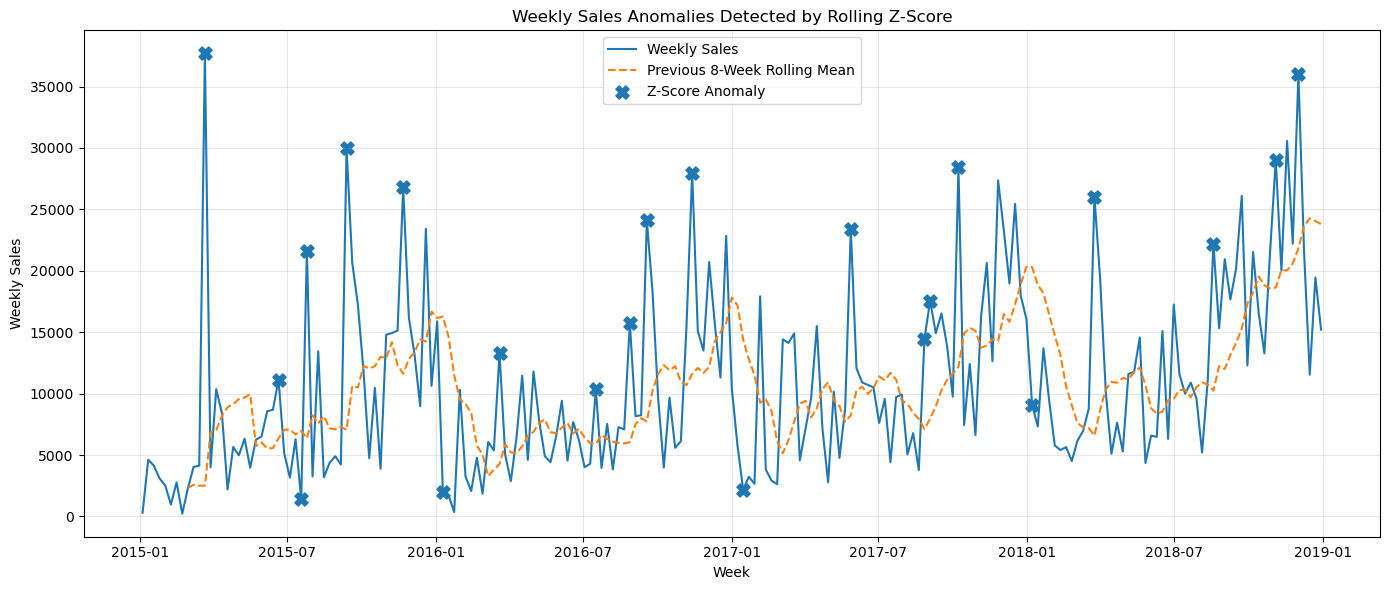

In [140]:
plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["Week"],
    anomaly_df["Weekly Sales"],
    label="Weekly Sales"
)

plt.plot(
    anomaly_df["Week"],
    anomaly_df["Rolling Mean"],
    linestyle="--",
    label="Previous 8-Week Rolling Mean"
)

plt.scatter(
    zscore_anomalies["Week"],
    zscore_anomalies["Weekly Sales"],
    marker="X",
    s=90,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomalies Detected by Rolling Z-Score")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [141]:
anomaly_df["Both Methods"] = (
    anomaly_df["Isolation Anomaly"] &
    anomaly_df["ZScore Anomaly"]
)

anomaly_df["Detection Result"] = np.select(
    [
        anomaly_df["Both Methods"],
        anomaly_df["Isolation Anomaly"],
        anomaly_df["ZScore Anomaly"]
    ],
    [
        "Both Methods",
        "Isolation Forest Only",
        "Z-Score Only"
    ],
    default="Normal"
)

In [142]:
method_comparison = (
    anomaly_df[
        anomaly_df["Detection Result"] != "Normal"
    ][
        [
            "Week",
            "Weekly Sales",
            "Isolation Anomaly",
            "Rolling Z Score",
            "ZScore Anomaly",
            "Detection Result"
        ]
    ]
    .sort_values("Week")
)

display(method_comparison.round(2))

,Week,Weekly Sales,Isolation Anomaly,Rolling Z Score,ZScore Anomaly,Detection Result
0,2015-01-04,304.51,True,NaN,False,Isolation Forest Only
5,2015-02-08,968.53,True,NaN,False,Isolation Forest Only
7,2015-02-22,224.91,True,NaN,False,Isolation Forest Only
11,2015-03-22,37703.66,True,25.81,True,Both Methods
24,2015-06-21,11139.44,False,2.94,True,Z-Score Only
28,2015-07-19,1387.69,True,-2.28,True,Both Methods
29,2015-07-26,21590.08,False,4.83,True,Z-Score Only
36,2015-09-13,29959.14,True,3.32,True,Both Methods
46,2015-11-22,26793.62,False,3.05,True,Z-Score Only
53,2016-01-10,1973.44,False,-2.36,True,Z-Score Only


In [143]:
comparison_counts = (
    anomaly_df["Detection Result"]
    .value_counts()
    .reset_index()
)

comparison_counts.columns = [
    "Detection Result",
    "Number of Weeks"
]

display(comparison_counts)

,Detection Result,Number of Weeks
0,Normal,181
1,Z-Score Only,17
2,Isolation Forest Only,6
3,Both Methods,5


In [144]:
both_count = anomaly_df["Both Methods"].sum()

isolation_only_count = (
    (
        anomaly_df["Isolation Anomaly"] &
        ~anomaly_df["ZScore Anomaly"]
    )
    .sum()
)

zscore_only_count = (
    (
        anomaly_df["ZScore Anomaly"] &
        ~anomaly_df["Isolation Anomaly"]
    )
    .sum()
)

print("Detected by both methods:", both_count)
print("Isolation Forest only:", isolation_only_count)
print("Z-Score only:", zscore_only_count)

Detected by both methods: 5
Isolation Forest only: 6
Z-Score only: 17


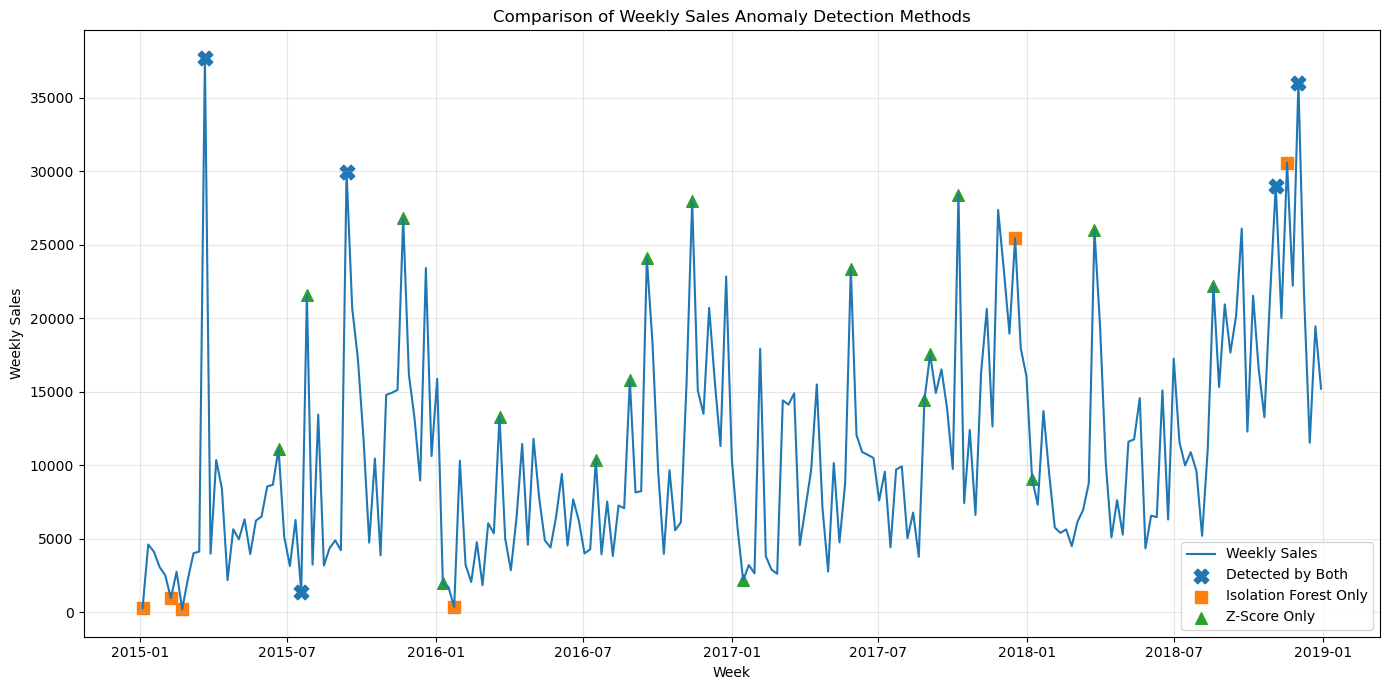

In [145]:
both_anomalies = anomaly_df[
    anomaly_df["Both Methods"]
]

isolation_only = anomaly_df[
    anomaly_df["Detection Result"] ==
    "Isolation Forest Only"
]

zscore_only = anomaly_df[
    anomaly_df["Detection Result"] ==
    "Z-Score Only"
]

plt.figure(figsize=(14, 7))

plt.plot(
    anomaly_df["Week"],
    anomaly_df["Weekly Sales"],
    label="Weekly Sales"
)

plt.scatter(
    both_anomalies["Week"],
    both_anomalies["Weekly Sales"],
    marker="X",
    s=110,
    label="Detected by Both"
)

plt.scatter(
    isolation_only["Week"],
    isolation_only["Weekly Sales"],
    marker="s",
    s=70,
    label="Isolation Forest Only"
)

plt.scatter(
    zscore_only["Week"],
    zscore_only["Weekly Sales"],
    marker="^",
    s=70,
    label="Z-Score Only"
)

plt.title("Comparison of Weekly Sales Anomaly Detection Methods")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/anomaly_method_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [146]:
def generate_anomaly_explanation(row):
    month = row["Week"].month
    sales_type = (
        "high"
        if row["Weekly Sales"] >= weekly_median
        else "low"
    )

    if sales_type == "high":
        if month in [9, 10, 11, 12]:
            return (
                "The high sales may be related to "
                "year-end seasonal demand, promotions "
                "or holiday purchasing."
            )

        if month in [3, 4]:
            return (
                "The spike may be connected to seasonal "
                "purchasing, bulk orders or a temporary "
                "promotional campaign."
            )

        return (
            "The unusually high sales may have resulted "
            "from bulk orders, a major promotion or an "
            "unrecorded external event."
        )

    if month in [1, 2]:
        return (
            "The low sales may reflect the weaker "
            "post-holiday demand observed during the "
            "beginning of the year."
        )

    return (
        "The unusually low sales may have been caused "
        "by reduced demand, stock shortages, delayed "
        "order recording or operational disruption."
    )

In [147]:
anomaly_report = anomaly_df[
    anomaly_df["Detection Result"] != "Normal"
].copy()

anomaly_report["Possible Explanation"] = (
    anomaly_report.apply(
        generate_anomaly_explanation,
        axis=1
    )
)

In [148]:
display(
    anomaly_report[
        [
            "Week",
            "Weekly Sales",
            "Detection Result",
            "Isolation Type",
            "ZScore Type",
            "Possible Explanation"
        ]
    ]
)

,Week,Weekly Sales,Detection Result,Isolation Type,ZScore Type,Possible Explanation
0,2015-01-04,304.5080,Isolation Forest Only,Unusually Low,Normal,The low sales may reflect the weaker post-holi...
5,2015-02-08,968.5340,Isolation Forest Only,Unusually Low,Normal,The low sales may reflect the weaker post-holi...
7,2015-02-22,224.9120,Isolation Forest Only,Unusually Low,Normal,The low sales may reflect the weaker post-holi...
11,2015-03-22,37703.6650,Both Methods,Unusually High,Unusually High,The spike may be connected to seasonal purchas...
24,2015-06-21,11139.4446,Z-Score Only,Normal,Unusually High,The unusually high sales may have resulted fro...
28,2015-07-19,1387.6860,Both Methods,Unusually Low,Unusually Low,The unusually low sales may have been caused b...
29,2015-07-26,21590.0800,Z-Score Only,Normal,Unusually High,The unusually high sales may have resulted fro...
36,2015-09-13,29959.1370,Both Methods,Unusually High,Unusually High,The high sales may be related to year-end seas...
46,2015-11-22,26793.6235,Z-Score Only,Normal,Unusually High,The high sales may be related to year-end seas...
53,2016-01-10,1973.4440,Z-Score Only,Normal,Unusually Low,The low sales may reflect the weaker post-holi...


In [149]:
top_three_anomalies = (
    anomaly_report
    .assign(
        Anomaly_Strength=
        anomaly_report["Rolling Z Score"].abs()
    )
    .sort_values(
        "Anomaly_Strength",
        ascending=False
    )
    .head(3)
)

display(
    top_three_anomalies[
        [
            "Week",
            "Weekly Sales",
            "Rolling Z Score",
            "Detection Result",
            "Possible Explanation"
        ]
    ].round(2)
)

,Week,Weekly Sales,Rolling Z Score,Detection Result,Possible Explanation
11,2015-03-22,37703.66,25.81,Both Methods,The spike may be connected to seasonal purchas...
168,2018-03-25,26029.90,11.30,Z-Score Only,The spike may be connected to seasonal purchas...
29,2015-07-26,21590.08,4.83,Z-Score Only,The unusually high sales may have resulted fro...


In [150]:
anomaly_df.to_csv(
    "outputs/weekly_sales_anomaly_results.csv",
    index=False
)

anomaly_report.to_csv(
    "outputs/detected_anomalies.csv",
    index=False
)

top_three_anomalies.to_csv(
    "outputs/top_three_anomalies.csv",
    index=False
)

print("Task 5 anomaly outputs saved successfully.")

Task 5 anomaly outputs saved successfully.


In [151]:
confirmed_anomalies = anomaly_df[
    anomaly_df["Both Methods"]
].copy()

display(
    confirmed_anomalies[
        [
            "Week",
            "Weekly Sales",
            "Rolling Z Score",
            "Isolation Score",
            "Isolation Type"
        ]
    ].sort_values(
        "Weekly Sales",
        ascending=False
    ).round(2)
)

,Week,Weekly Sales,Rolling Z Score,Isolation Score,Isolation Type
11,2015-03-22,37703.66,25.81,-0.20,Unusually High
204,2018-12-02,35998.90,2.45,-0.17,Unusually High
36,2015-09-13,29959.14,3.32,-0.05,Unusually High
200,2018-11-04,29017.47,2.25,-0.02,Unusually High
28,2015-07-19,1387.69,-2.28,-0.01,Unusually Low


In [152]:
top_three_confirmed_anomalies = (
    confirmed_anomalies
    .assign(
        Deviation_From_Rolling_Mean=(
            confirmed_anomalies["Weekly Sales"] -
            confirmed_anomalies["Rolling Mean"]
        ).abs()
    )
    .sort_values(
        "Deviation_From_Rolling_Mean",
        ascending=False
    )
    .head(3)
)

display(
    top_three_confirmed_anomalies[
        [
            "Week",
            "Weekly Sales",
            "Rolling Mean",
            "Rolling Z Score",
            "Isolation Type"
        ]
    ].round(2)
)

,Week,Weekly Sales,Rolling Mean,Rolling Z Score,Isolation Type
11,2015-03-22,37703.66,2505.62,25.81,Unusually High
36,2015-09-13,29959.14,7047.34,3.32,Unusually High
204,2018-12-02,35998.90,21833.72,2.45,Unusually High


In [153]:
### Weekly Sales Anomaly Detection Findings

Isolation Forest detected 11 anomalous weeks, while the rolling Z-score
method detected 22 anomalous weeks. Both methods agreed on 5 weeks.
Isolation Forest alone detected 6 weeks, and the rolling Z-score method
alone detected 17 weeks.

The methods produced different results because they define unusual sales
differently. Isolation Forest identifies values that are unusual compared
with the complete four-year dataset. The rolling Z-score method compares
each week with the preceding eight weeks and therefore responds more
strongly to sudden local changes.

The week ending 22 March 2015 recorded sales of 37,703.66 and was detected
by both methods. The unusually high sales may have resulted from a bulk
order, a seasonal purchasing event or a temporary promotion.

Several high anomalies were also observed during September, November and
December. These periods match the strong year-end seasonality identified
earlier in the analysis and may be associated with festive demand,
promotional campaigns or bulk purchasing.

The low anomaly recorded during July 2015 may indicate temporarily weak
demand, inventory shortages, delayed order recording or another operational
issue. Since the dataset does not contain promotion or stock information,
these explanations should be treated as possible causes rather than
confirmed facts.

The first eight weekly observations did not have rolling Z-scores because
there was insufficient prior data to calculate an eight-week rolling mean
and standard deviation.

SyntaxError: invalid syntax (1186635594.py, line 3)

In [ ]:
subcategory_total_sales = (
    superstore_df
    .groupby("Sub-Category")["Sales"]
    .sum()
    .rename("Total Sales")
)

In [ ]:
subcategory_year_sales = (
    superstore_df
    .groupby(
        ["Sub-Category", "Year"]
    )["Sales"]
    .sum()
    .unstack(fill_value=0)
)

display(
    subcategory_year_sales.round(2)
)

In [ ]:
subcategory_yoy_growth = (
    subcategory_year_sales
    .replace(0, np.nan)
    .pct_change(axis=1) * 100
)

average_yoy_growth = (
    subcategory_yoy_growth
    .replace([np.inf, -np.inf], np.nan)
    .mean(axis=1)
    .fillna(0)
    .rename("Average YoY Growth")
)

display(
    average_yoy_growth
    .sort_values(ascending=False)
    .round(2)
)

In [ ]:
subcategory_monthly_sales = (
    superstore_df
    .groupby(
        [
            "Sub-Category",
            pd.Grouper(
                key="Order Date",
                freq="MS"
            )
        ]
    )["Sales"]
    .sum()
    .unstack(fill_value=0)
)

monthly_volatility = (
    subcategory_monthly_sales
    .std(axis=1)
    .rename("Monthly Sales Volatility")
)

In [ ]:
subcategory_order_sales = (
    superstore_df
    .groupby(
        ["Sub-Category", "Order ID"]
    )["Sales"]
    .sum()
    .reset_index()
)

average_order_value = (
    subcategory_order_sales
    .groupby("Sub-Category")["Sales"]
    .mean()
    .rename("Average Order Value")
)

In [ ]:
clustering_df = pd.concat(
    [
        subcategory_total_sales,
        average_yoy_growth,
        monthly_volatility,
        average_order_value
    ],
    axis=1
).reset_index()

display(
    clustering_df.round(2)
)

In [ ]:
print("Number of sub-categories:", len(clustering_df))
print(clustering_df.isnull().sum())

In [ ]:
clustering_df = clustering_df.replace(
    [np.inf, -np.inf],
    np.nan
)

clustering_df = clustering_df.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
cluster_features = [
    "Total Sales",
    "Average YoY Growth",
    "Monthly Sales Volatility",
    "Average Order Value"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    clustering_df[cluster_features]
)

In [ ]:
inertia_values = []
silhouette_values = []

cluster_range = range(2, 7)

for number_of_clusters in cluster_range:

    model = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        scaled_features
    )

    inertia_values.append(
        model.inertia_
    )

    silhouette_values.append(
        silhouette_score(
            scaled_features,
            labels
        )
    )

In [ ]:
cluster_evaluation = pd.DataFrame({
    "Number of Clusters": list(cluster_range),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

display(
    cluster_evaluation.round(4)
)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Inertia")
plt.xticks(list(cluster_range))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(cluster_range))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
optimal_clusters = 4

In [ ]:
kmeans_model = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=20
)

clustering_df["Cluster"] = (
    kmeans_model.fit_predict(
        scaled_features
    )
)

In [ ]:
display(
    clustering_df.sort_values(
        "Cluster"
    ).round(2)
)

In [ ]:
cluster_profiles = (
    clustering_df
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profiles["Number of Sub-Categories"] = (
    clustering_df
    .groupby("Cluster")
    .size()
)

display(cluster_profiles)

In [ ]:
cluster_label_map = {}

remaining_clusters = list(
    cluster_profiles.index
)

high_volume_cluster = (
    cluster_profiles["Total Sales"].idxmax()
)

cluster_label_map[
    high_volume_cluster
] = "High Volume Demand"

remaining_clusters.remove(
    high_volume_cluster
)

growing_cluster = (
    cluster_profiles
    .loc[remaining_clusters, "Average YoY Growth"]
    .idxmax()
)

cluster_label_map[
    growing_cluster
] = "Growing Demand"

remaining_clusters.remove(
    growing_cluster
)

declining_cluster = (
    cluster_profiles
    .loc[remaining_clusters, "Average YoY Growth"]
    .idxmin()
)

cluster_label_map[
    declining_cluster
] = "Declining Demand"

remaining_clusters.remove(
    declining_cluster
)

for cluster in remaining_clusters:
    cluster_label_map[
        cluster
    ] = "Low Volume or Variable Demand"

In [ ]:
clustering_df["Demand Segment"] = (
    clustering_df["Cluster"]
    .map(cluster_label_map)
)

display(
    clustering_df[
        [
            "Sub-Category",
            "Total Sales",
            "Average YoY Growth",
            "Monthly Sales Volatility",
            "Average Order Value",
            "Cluster",
            "Demand Segment"
        ]
    ]
    .sort_values(
        ["Cluster", "Total Sales"],
        ascending=[True, False]
    )
    .round(2)
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_components = pca.fit_transform(
    scaled_features
)

clustering_df["PCA 1"] = (
    pca_components[:, 0]
)

clustering_df["PCA 2"] = (
    pca_components[:, 1]
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

In [ ]:
plt.figure(figsize=(11, 7))

for cluster_number in sorted(
    clustering_df["Cluster"].unique()
):
    cluster_points = clustering_df[
        clustering_df["Cluster"] ==
        cluster_number
    ]

    label_name = cluster_label_map[
        cluster_number
    ]

    plt.scatter(
        cluster_points["PCA 1"],
        cluster_points["PCA 2"],
        s=100,
        label=label_name
    )

for _, row in clustering_df.iterrows():
    plt.annotate(
        row["Sub-Category"],
        (
            row["PCA 1"],
            row["PCA 2"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("Product Demand Segments by Sub-Category")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/product_demand_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
stocking_strategy_map = {
    "High Volume Demand":
        "Maintain higher safety stock, use frequent replenishment and closely monitor stock-out risk.",

    "Growing Demand":
        "Increase inventory gradually, review forecasts monthly and expand supplier capacity where required.",

    "Declining Demand":
        "Reduce purchase quantities, avoid excess safety stock and use promotions to clear slow-moving inventory.",

    "Low Volume or Variable Demand":
        "Keep limited buffer stock, use smaller and more frequent orders and consider demand-based replenishment."
}

In [ ]:
clustering_df["Recommended Stocking Strategy"] = (
    clustering_df["Demand Segment"]
    .map(stocking_strategy_map)
)

display(
    clustering_df[
        [
            "Sub-Category",
            "Demand Segment",
            "Recommended Stocking Strategy"
        ]
    ]
)

In [ ]:
clustering_df.to_csv(
    "outputs/product_demand_segments.csv",
    index=False
)

cluster_profiles.to_csv(
    "outputs/cluster_profiles.csv"
)

print(
    "Task 6 clustering outputs saved successfully."
)

In [ ]:
### Selection of the Number of Clusters

The elbow curve shows a clear reduction in inertia up to four clusters,
after which the improvement becomes smaller. The four-cluster solution
also produced the highest silhouette score of 0.4783.

Although six clusters produced a similar silhouette score of 0.4752,
four clusters were selected because they provide a simpler and more
business-interpretable segmentation for only 17 product sub-categories.

In [ ]:
corrected_cluster_label_map = {
    0: "High Value, High Volatility",
    1: "Low Volume, Moderate Growth",
    2: "High Volume, Core Demand",
    3: "Irregular or Rebound Demand"
}

clustering_df["Demand Segment"] = (
    clustering_df["Cluster"]
    .map(corrected_cluster_label_map)
)

display(
    clustering_df[
        [
            "Sub-Category",
            "Total Sales",
            "Average YoY Growth",
            "Monthly Sales Volatility",
            "Average Order Value",
            "Cluster",
            "Demand Segment"
        ]
    ]
    .sort_values(
        ["Cluster", "Total Sales"],
        ascending=[True, False]
    )
    .round(2)
)

In [ ]:
corrected_stocking_strategy_map = {
    "High Value, High Volatility":
        "Maintain limited safety stock, use tighter reorder controls, "
        "monitor demand frequently and avoid excessive capital being "
        "locked in expensive inventory.",

    "Low Volume, Moderate Growth":
        "Use lean inventory levels, smaller purchase quantities and "
        "regular replenishment based on recent sales movement.",

    "High Volume, Core Demand":
        "Maintain higher safety stock, replenish frequently and closely "
        "monitor stock-out risk because these products contribute heavily "
        "to total sales.",

    "Irregular or Rebound Demand":
        "Use cautious purchasing, manually review recent demand changes "
        "and avoid large stock increases until the growth pattern becomes stable."
}

clustering_df["Recommended Stocking Strategy"] = (
    clustering_df["Demand Segment"]
    .map(corrected_stocking_strategy_map)
)

display(
    clustering_df[
        [
            "Sub-Category",
            "Demand Segment",
            "Recommended Stocking Strategy"
        ]
    ]
)

In [ ]:
clustering_df.to_csv(
    "outputs/product_demand_segments.csv",
    index=False
)

In [ ]:
year_columns = sorted(
    subcategory_year_sales.columns
)

first_year = year_columns[0]
last_year = year_columns[-1]

number_of_periods = (
    last_year - first_year
)

subcategory_cagr = (
    (
        subcategory_year_sales[last_year] /
        subcategory_year_sales[first_year]
    ) ** (1 / number_of_periods) - 1
) * 100

subcategory_cagr = (
    subcategory_cagr
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .rename("Sales CAGR")
)

display(
    subcategory_cagr
    .sort_values(ascending=False)
    .round(2)
)

In [ ]:
clustering_df = clustering_df.merge(
    subcategory_cagr.reset_index(),
    on="Sub-Category",
    how="left"
)

In [ ]:
cluster_features = [
    "Total Sales",
    "Sales CAGR",
    "Monthly Sales Volatility",
    "Average Order Value"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    clustering_df[cluster_features]
)

kmeans_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

clustering_df["Cluster"] = (
    kmeans_model.fit_predict(
        scaled_features
    )
)

In [ ]:
### Product Demand Segmentation Findings

Four demand clusters were selected because the elbow curve showed a clear
bend at four clusters and the four-cluster solution produced the highest
silhouette score of 0.4783.

The High Volume, Core Demand cluster contains Accessories, Binders, Chairs,
Phones, Storage and Tables. These sub-categories generate the highest
overall sales and should receive frequent replenishment and sufficient
safety stock.

Copiers and Machines form a High Value, High Volatility cluster. These
products have large average order values and highly variable monthly sales.
The business should avoid excessive inventory while monitoring demand and
supplier lead times closely.

The Low Volume, Moderate Growth cluster includes Appliances, Art, Bookcases,
Envelopes, Fasteners, Furnishings, Labels and Paper. These products require
lean inventory levels and smaller, regular replenishment orders.

Supplies forms a separate Irregular or Rebound Demand cluster. Its very high
average year-over-year growth was largely caused by a sharp sales decline
in 2016 followed by a recovery in 2017. Therefore, its reported growth rate
should not be interpreted as stable long-term growth.

The clustering results show that one inventory policy should not be applied
to every product group. High-volume products require stronger stock
availability, while expensive and volatile products require tighter control
to avoid excess working capital.

In [ ]:
print(
    "PC1 explained variance:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2 explained variance:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

In [ ]:
games_analysis_df = games_df.copy()

games_analysis_df["Year"] = pd.to_numeric(
    games_analysis_df["Year"],
    errors="coerce"
)

games_analysis_df = games_analysis_df.dropna(
    subset=["Year"]
).copy()

games_analysis_df["Year"] = (
    games_analysis_df["Year"].astype(int)
)

sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

for column in sales_columns:
    games_analysis_df[column] = pd.to_numeric(
        games_analysis_df[column],
        errors="coerce"
    )

games_analysis_df = games_analysis_df.dropna(
    subset=["Global_Sales"]
)

In [ ]:
game_yearly_sales = (
    games_analysis_df
    .groupby("Year", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Year")
)

display(game_yearly_sales.head())

In [ ]:
game_anomaly_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

game_yearly_sales["Isolation Label"] = (
    game_anomaly_model.fit_predict(
        game_yearly_sales[["Global_Sales"]]
    )
)

game_yearly_sales["Isolation Anomaly"] = (
    game_yearly_sales["Isolation Label"] == -1
)

In [ ]:
game_mean = (
    game_yearly_sales["Global_Sales"].mean()
)

game_std = (
    game_yearly_sales["Global_Sales"].std()
)

game_yearly_sales["Z Score"] = (
    game_yearly_sales["Global_Sales"] -
    game_mean
) / game_std

game_yearly_sales["ZScore Anomaly"] = (
    game_yearly_sales["Z Score"].abs() > 2
)

display(
    game_yearly_sales[
        game_yearly_sales[
            ["Isolation Anomaly", "ZScore Anomaly"]
        ].any(axis=1)
    ].round(2)
)

In [ ]:
game_anomalies = game_yearly_sales[
    game_yearly_sales[
        ["Isolation Anomaly", "ZScore Anomaly"]
    ].any(axis=1)
]

plt.figure(figsize=(12, 6))

plt.plot(
    game_yearly_sales["Year"],
    game_yearly_sales["Global_Sales"],
    marker="o",
    label="Yearly Global Video Game Sales"
)

plt.scatter(
    game_anomalies["Year"],
    game_anomalies["Global_Sales"],
    marker="X",
    s=100,
    label="Detected Anomaly"
)

plt.title("Yearly Video Game Sales Anomalies")
plt.xlabel("Year")
plt.ylabel("Global Sales in Millions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/video_game_sales_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
retail_yearly_sales = (
    superstore_df
    .groupby("Year", as_index=False)["Sales"]
    .sum()
    .rename(
        columns={
            "Sales": "Retail Sales Revenue"
        }
    )
)

multi_source_yearly = retail_yearly_sales.merge(
    game_yearly_sales[
        ["Year", "Global_Sales"]
    ],
    on="Year",
    how="outer"
)

multi_source_yearly.rename(
    columns={
        "Global_Sales":
        "Video Game Global Sales Millions"
    },
    inplace=True
)

display(
    multi_source_yearly.sort_values("Year")
)

In [ ]:
### Supplementary Multi-Source Analysis

The Superstore and Video Game Sales datasets were combined only at the
year level to demonstrate multi-source data integration. They were not
merged at the individual record level because they represent different
industries and do not share customer, product or transaction identifiers.

Retail sales are measured as revenue, while video-game sales are measured
in millions of units. Therefore, the merged table was used only for data
integration practice and not as an input to the retail forecasting models.